# Picking equation process

This notebook recreates the selection path:
1) Screen 6 candidate equations and compute R2 on mean-averaged data.
2) Explain why hormesis is favored and show hormesis fits.
3) Move from hormesis to PK-PD with elimination.
4) Regenerate the all_equations_coefficients.xlsx workbook (one sheet per equation).
5) Summarize R2 for all equations on mean-averaged data (Contractility and O2).


## Setup
Set project paths and confirm data availability.


In [21]:
# Cell #2: Setup and Path Configuration
# Depends on: None

# Core imports
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Find project root - look for EQN_Coefficients directory
current_dir = Path.cwd()

# Path discovery logic for Cardiac_RODEO project
if current_dir.name == 'Prediction_Models' or current_dir.name == 'Picking Equations':
    PROJECT_ROOT = current_dir.parent
elif (current_dir / 'EQN_Coefficients').exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / 'EQN_Coefficients').exists():
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

# Directory paths - COEFF_DIR points to outputs where new coefficients will be generated
NOTEBOOK_DIR = current_dir if current_dir.name == 'Picking Equations' else current_dir / 'Picking Equations'
OUTPUT_DIR = NOTEBOOK_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# COEFF_DIR references the outputs folder where new coefficients are created
COEFF_DIR = OUTPUT_DIR

# Legacy picking dir (for loading old R2 CSVs if they exist)
PICKING_DIR = NOTEBOOK_DIR

# Data file paths
CONTRACTILITY_FILE = PROJECT_ROOT / 'Cleaned_Data' / 'Heart_Contractility_Averaged.xlsx'
O2_FILE = PROJECT_ROOT / 'Cleaned_Data' / 'O2_Mean_Averaged.xlsx'
CMAX_CSV = PROJECT_ROOT / 'Cleaned_Data' / 'drug_Cmax.csv'

print('Project root:', PROJECT_ROOT)
print('Notebook dir:', NOTEBOOK_DIR)
print('Output dir:', OUTPUT_DIR)
print('Coefficient dir (outputs):', COEFF_DIR)
print('\nData file checks:')
print('  Contractility file exists:', CONTRACTILITY_FILE.exists())
print('  O2 file exists:', O2_FILE.exists())
print('  Cmax file exists:', CMAX_CSV.exists())


Project root: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO
Notebook dir: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Picking Equations
Output dir: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Picking Equations\outputs
Coefficient dir (outputs): c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Picking Equations\outputs

Data file checks:
  Contractility file exists: True
  O2 file exists: True
  Cmax file exists: True


## Step 1: Screen 6 candidate equations (R2)
This is the same logic as `picking equation/fit_equation_comparison.py`, copied into the notebook.


In [22]:
import re
import warnings
from scipy.optimize import curve_fit

warnings.filterwarnings('ignore')

def parse_conc(col_name):
    if pd.isna(col_name):
        return None
    col_str = str(col_name).replace('_', '.')
    match = re.search(r'(\d+\.?\d*)', col_str)
    if match:
        return float(match.group(1))
    return None

def normalize_drug_name(name):
    return re.sub(r'\s|\(.*?\)', '', str(name).lower())

def parse_excel_data(excel_file, cmax_csv, response_type='O2'):
    cmax_df = pd.read_csv(cmax_csv)
    cmax_df['DrugKey'] = cmax_df['Drug'].apply(normalize_drug_name)
    cmax_dict = dict(zip(cmax_df['DrugKey'], cmax_df['Cmax_uM']))

    xl_file = pd.ExcelFile(excel_file)
    sheet_names = xl_file.sheet_names

    skip_sheets = ['all_drugs', 'all_drugs smoothed', 'smoothed all data',
                   'smoothed_all_data', 'all data', 'alldata']
    data_dict = {}

    for sheet_name in sheet_names:
        if normalize_drug_name(sheet_name) in [s.lower() for s in skip_sheets]:
            continue
        try:
            df = pd.read_excel(excel_file, sheet_name=sheet_name)
            if df.empty or len(df.columns) < 2:
                continue

            time_col = pd.to_numeric(df.iloc[:, 0].values, errors='coerce')
            time_list = []
            conc_list = []
            response_list = []

            for col_idx in range(1, len(df.columns)):
                col_name = df.columns[col_idx]
                conc_val = parse_conc(col_name)
                if conc_val is None:
                    continue
                response_vals = pd.to_numeric(df.iloc[:, col_idx], errors='coerce').values

                valid_mask = np.isfinite(time_col) & np.isfinite(response_vals)
                time_list.extend(time_col[valid_mask])
                conc_list.extend([conc_val] * np.sum(valid_mask))
                response_list.extend(response_vals[valid_mask])

            if len(response_list) < 25:
                continue

            time_arr = np.array(time_list)
            conc_arr = np.array(conc_list)
            response_arr = np.array(response_list)

            if response_type == 'O2':
                valid = (time_arr >= 0) & (time_arr <= 96) & (response_arr < 200) & np.isfinite(time_arr) & np.isfinite(conc_arr) & np.isfinite(response_arr)
            else:
                valid = (time_arr >= 0) & (time_arr <= 96) & np.isfinite(time_arr) & np.isfinite(conc_arr) & np.isfinite(response_arr)

            time_arr = time_arr[valid]
            conc_arr = conc_arr[valid]
            response_arr = response_arr[valid]

            if len(response_arr) < 25:
                continue

            drug_key = normalize_drug_name(sheet_name)
            cmax = cmax_dict.get(drug_key, None)
            if cmax is None or not np.isfinite(cmax) or cmax <= 0:
                cmax = np.max(conc_arr)

            conc_norm = conc_arr / cmax

            data_dict[sheet_name] = {
                'time': time_arr,
                'conc': conc_arr,
                'conc_norm': conc_norm,
                'response': response_arr,
                'cmax': cmax
            }
        except Exception as e:
            print(f'Error processing {sheet_name}: {e}')
            continue

    return data_dict

def eq1_dual_exponential(X, R0, E_benefit, E_tox, kappa_b, kappa_t, tau_b, tau_t, n_b, n_t, m_b, m_t):
    C_norm, t = X[:, 0], X[:, 1]
    t = np.maximum(t, 0)
    kappa_b = max(kappa_b, 1e-9)
    kappa_t = max(kappa_t, 1e-9)
    tau_b = max(tau_b, 1e-9)
    tau_t = max(tau_t, 1e-9)

    benefit = E_benefit * (1 - np.exp(-kappa_b * (C_norm**n_b) * ((t/tau_b)**m_b)))
    toxic = E_tox * (1 - np.exp(-kappa_t * (C_norm**n_t) * ((t/tau_t)**m_t)))
    return R0 + benefit - toxic

def eq2_bivariate_gaussian(X, R0, A1, A2, mu_c1, mu_t1, sigma_c1, sigma_t1, rho1, mu_c2, mu_t2, sigma_c2, sigma_t2, rho2):
    C_norm, t = X[:, 0], X[:, 1]
    z1_c = (C_norm - mu_c1) / max(sigma_c1, 1e-9)
    z1_t = (t - mu_t1) / max(sigma_t1, 1e-9)
    gauss1 = A1 * np.exp(-0.5 * (z1_c**2 + z1_t**2 + 2*rho1*z1_c*z1_t))
    z2_c = (C_norm - mu_c2) / max(sigma_c2, 1e-9)
    z2_t = (t - mu_t2) / max(sigma_t2, 1e-9)
    gauss2 = A2 * np.exp(-0.5 * (z2_c**2 + z2_t**2 + 2*rho2*z2_c*z2_t))
    return R0 + gauss1 - gauss2

def eq3_gaussian_hill_hybrid(X, R0, E_max, mu_c, sigma_c, tau, m, E_tox, n, TC50_norm, tau_tox):
    C_norm, t = X[:, 0], X[:, 1]
    t = np.maximum(t, 1e-9)
    gauss_conc = np.exp(-0.5 * ((C_norm - mu_c) / max(sigma_c, 1e-9))**2)
    hill_time = (t/tau)**m / (1 + (t/tau)**m)
    benefit = E_max * gauss_conc * hill_time

    toxic_conc = (C_norm**n) / (max(TC50_norm, 1e-9)**n + C_norm**n)
    toxic_time = 1 - np.exp(-t / max(tau_tox, 1e-9))
    toxic = E_tox * toxic_conc * toxic_time

    return R0 + benefit - toxic

def eq4_polynomial(X, R0, a1, a2, a3, a4, a5, a6, a7, a8, a9):
    C_norm, t = X[:, 0], X[:, 1]
    return (R0 + a1*C_norm + a2*t + a3*C_norm**2 + a4*t**2 + a5*C_norm*t +
            a6*C_norm**3 + a7*t**3 + a8*C_norm**2*t + a9*C_norm*t**2)

def eq5_modified_hill_hormesis(X, R0, E_benefit, E_tox, EC50_b_norm, TC50_norm, n_b, n_t, tau_b, tau_t):
    C_norm, t = X[:, 0], X[:, 1]
    t = np.maximum(t, 1e-9)
    tau_b = max(tau_b, 1e-9)
    tau_t = max(tau_t, 1e-9)

    benefit_conc = (C_norm**n_b) / (max(EC50_b_norm, 1e-9)**n_b + C_norm**n_b)
    benefit_time = 1 - np.exp(-t / tau_b)
    benefit = E_benefit * benefit_conc * benefit_time

    toxic_conc = (C_norm**n_t) / (max(TC50_norm, 1e-9)**n_t + C_norm**n_t)
    toxic_time = 1 - np.exp(-t / tau_t)
    toxic = E_tox * toxic_conc * toxic_time

    return R0 + benefit - toxic

def eq6_gaussian_ridge(X, R0, A, B, mu_c, sigma_c, mu_tox, sigma_tox, kappa, tau, m, lam):
    C_norm, t = X[:, 0], X[:, 1]
    t = np.maximum(t, 1e-9)
    tau = max(tau, 1e-9)
    gauss_benefit = np.exp(-0.5 * ((C_norm - mu_c) / max(sigma_c, 1e-9))**2)
    time_benefit = 1 - np.exp(-kappa * (t/tau)**m)
    benefit = A * gauss_benefit * time_benefit

    gauss_toxic = np.exp(-0.5 * ((C_norm - mu_tox) / max(sigma_tox, 1e-9))**2)
    time_toxic = 1 - np.exp(-lam * t)
    toxic = B * gauss_toxic * time_toxic

    return R0 + benefit - toxic

def calculate_r2_with_components(y_true, y_pred):
    """
    Calculate R², SSE, and SSY (matches MATLAB implementation)
    
    Returns:
    --------
    dict with keys: 'R2', 'SSE', 'SSY', 'N'
    """
    y_mean = np.mean(y_true)
    SSE = np.sum((y_true - y_pred)**2)
    SSY = np.sum((y_true - y_mean)**2)
    
    if SSY == 0:
        R2 = np.nan
    else:
        R2 = 1 - (SSE / SSY)
    
    return {
        'R2': R2,
        'SSE': SSE,
        'SSY': SSY,
        'N': len(y_true)
    }

def fit_equation(data, eq_func, param_bounds, initial_guess, maxfev=5000):
    """
    Fit equation and return detailed statistics including SSE, SSY, R²
    """
    time = data['time']
    conc_norm = data['conc_norm']
    response = data['response']
    X = np.column_stack([conc_norm, time])
    try:
        popt, _ = curve_fit(eq_func, X, response, p0=initial_guess, bounds=param_bounds, maxfev=maxfev)
        y_pred = eq_func(X, *popt)
        stats = calculate_r2_with_components(response, y_pred)
        return stats['R2'], popt, stats
    except Exception:
        return np.nan, None, {'R2': np.nan, 'SSE': np.nan, 'SSY': np.nan, 'N': len(response)}

def fit_all_equations(excel_file, cmax_csv, response_type='O2'):
    data_dict = parse_excel_data(excel_file, cmax_csv, response_type=response_type)

    if response_type == 'Contractility':
        R0_bounds = [0, 0.2]
        Emax_bounds = [0, 0.2]
        A_bounds = [0, 0.2]
    else:
        R0_bounds = [5, 25]
        Emax_bounds = [0, 100]
        A_bounds = [0, 100]

    equations = {
        'Eq1_Dual_Exponential': {
            'func': eq1_dual_exponential,
            'bounds': ([R0_bounds[0], 0, 0, 1e-6, 1e-6, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
                      [R0_bounds[1], Emax_bounds[1], Emax_bounds[1], 100, 100, 96, 96, 6, 6, 6, 6]),
            'initial': [np.mean(R0_bounds), Emax_bounds[1]*0.2, Emax_bounds[1]*0.3, 1.0, 1.0, 24, 24, 2.0, 2.0, 2.0, 2.0]
        },
        'Eq2_Bivariate_Gaussian': {
            'func': eq2_bivariate_gaussian,
            'bounds': ([R0_bounds[0], 0, 0, 0, 0, 0.01, 0.01, -0.9, 0, 0, 0.01, 0.01, -0.9],
                      [R0_bounds[1], A_bounds[1], A_bounds[1], 2, 96, 2, 96, 0.9, 2, 96, 2, 96, 0.9]),
            'initial': [np.mean(R0_bounds), A_bounds[1]*0.2, A_bounds[1]*0.3, 0.5, 24, 0.3, 12, 0, 1.5, 48, 0.3, 12, 0]
        },
        'Eq3_Gaussian_Hill_Hybrid': {
            'func': eq3_gaussian_hill_hybrid,
            'bounds': ([R0_bounds[0], 0, 0, 0.01, 0.1, 0.1, 0, 0.1, 0.01, 0.1],
                      [R0_bounds[1], Emax_bounds[1], 2, 2, 96, 6, Emax_bounds[1], 6, 2, 96]),
            'initial': [np.mean(R0_bounds), Emax_bounds[1]*0.3, 0.5, 0.3, 24, 2.0, Emax_bounds[1]*0.3, 2.0, 0.5, 12]
        },
        'Eq4_Polynomial': {
            'func': eq4_polynomial,
            'bounds': ([R0_bounds[0], -Emax_bounds[1], -Emax_bounds[1], -Emax_bounds[1], -Emax_bounds[1], -Emax_bounds[1], -Emax_bounds[1], -Emax_bounds[1], -Emax_bounds[1], -Emax_bounds[1]],
                      [R0_bounds[1], Emax_bounds[1], Emax_bounds[1], Emax_bounds[1], Emax_bounds[1], Emax_bounds[1], Emax_bounds[1], Emax_bounds[1], Emax_bounds[1], Emax_bounds[1]]),
            'initial': [np.mean(R0_bounds), 0, 0, 0, 0, 0, 0, 0, 0, 0]
        },
        'Eq5_Modified_Hill_Hormesis': {
            'func': eq5_modified_hill_hormesis,
            'bounds': ([R0_bounds[0], 0, 0, 0.01, 0.01, 0.1, 0.1, 0.1, 0.1],
                      [R0_bounds[1], Emax_bounds[1], Emax_bounds[1], 2, 2, 6, 6, 96, 96]),
            'initial': [np.mean(R0_bounds), Emax_bounds[1]*0.2, Emax_bounds[1]*0.3, 0.3, 1.0, 2.0, 2.0, 24, 24]
        },
        'Eq6_Gaussian_Ridge': {
            'func': eq6_gaussian_ridge,
            'bounds': ([R0_bounds[0], 0, 0, 0, 0.01, 0, 0.01, 1e-6, 0.1, 0.1, 1e-6],
                      [R0_bounds[1], A_bounds[1], A_bounds[1], 2, 2, 2, 2, 100, 96, 6, 1]),
            'initial': [np.mean(R0_bounds), A_bounds[1]*0.3, A_bounds[1]*0.3, 0.5, 0.3, 1.5, 0.3, 1.0, 24, 2.0, 0.1]
        }
    }

    results = []
    for drug_name, data in data_dict.items():
        drug_results = {'Drug': drug_name}
        for eq_name, eq_config in equations.items():
            r2, params, stats = fit_equation(data, eq_config['func'], eq_config['bounds'], eq_config['initial'])
            drug_results[eq_name] = r2
            drug_results[f'{eq_name}_SSE'] = stats['SSE']
            drug_results[f'{eq_name}_SSY'] = stats['SSY']
            drug_results[f'{eq_name}_N'] = stats['N']
        results.append(drug_results)

    results_df = pd.DataFrame(results)
    return results_df

In [23]:
from IPython.display import display

def load_existing_r2_csv(response_type):
    if not PICKING_DIR.exists():
        return None
    candidates = list(PICKING_DIR.glob('equation_comparison_r2*.csv'))
    if response_type.lower() == 'contractility':
        for p in candidates:
            if 'contractility' in p.name.lower():
                return pd.read_csv(p)
    if response_type.lower() == 'o2':
        for p in candidates:
            name_lower = p.name.lower()
            if 'meanaveraged' in name_lower or 'mean_averaged' in name_lower or 'o2' in name_lower:
                return pd.read_csv(p)
    return None

def summarize_results(df, label):
    # Get R2 columns
    eq_cols = [c for c in df.columns if c != 'Drug' and not c.endswith('_SSE') and not c.endswith('_SSY') and not c.endswith('_N')]
    
    print('\n' + '='*80)
    print(label)
    print('='*80)
    display(df[eq_cols].describe())

    best_eq = df[eq_cols].idxmax(axis=1)
    win_counts = best_eq.value_counts()
    print('Wins per equation:')
    display(win_counts)

    avg_r2 = df[eq_cols].mean().sort_values(ascending=False)
    print('Average R2 per equation:')
    display(avg_r2)

# Prefer existing outputs if present, otherwise run the fits
USE_EXISTING = False  # Set to False to recalculate with SSE/SSY
SAVE_DETAILED_STATS = True  # Set to True to save detailed statistics

contractility_results = load_existing_r2_csv('contractility') if USE_EXISTING else None
if contractility_results is None:
    print("Recalculating 6-equation screen with detailed statistics (R², SSE, SSY)...")
    contractility_results = fit_all_equations(str(CONTRACTILITY_FILE), str(CMAX_CSV), response_type='Contractility')
    
    # Save with detailed stats
    if SAVE_DETAILED_STATS:
        contractility_results.to_csv(OUTPUT_DIR / 'equation_comparison_detailed_contractility.csv', index=False)
        print(f"Saved detailed results to: {OUTPUT_DIR / 'equation_comparison_detailed_contractility.csv'}")
    
    # Also save R2-only version for compatibility
    r2_cols = ['Drug'] + [c for c in contractility_results.columns if not c.endswith('_SSE') and not c.endswith('_SSY') and not c.endswith('_N')]
    contractility_results[r2_cols].to_csv(OUTPUT_DIR / 'equation_comparison_r2_contractility_mean_averaged.csv', index=False)

o2_results = load_existing_r2_csv('o2') if USE_EXISTING else None
if o2_results is None:
    print("Recalculating 6-equation screen with detailed statistics (R², SSE, SSY)...")
    o2_results = fit_all_equations(str(O2_FILE), str(CMAX_CSV), response_type='O2')
    
    # Save with detailed stats
    if SAVE_DETAILED_STATS:
        o2_results.to_csv(OUTPUT_DIR / 'equation_comparison_detailed_o2.csv', index=False)
        print(f"Saved detailed results to: {OUTPUT_DIR / 'equation_comparison_detailed_o2.csv'}")
    
    # Also save R2-only version for compatibility
    r2_cols = ['Drug'] + [c for c in o2_results.columns if not c.endswith('_SSE') and not c.endswith('_SSY') and not c.endswith('_N')]
    o2_results[r2_cols].to_csv(OUTPUT_DIR / 'equation_comparison_r2_o2_mean_averaged.csv', index=False)

summarize_results(contractility_results, 'Contractility mean-averaged: 6-equation screen')
summarize_results(o2_results, 'O2 mean-averaged: 6-equation screen')

Recalculating 6-equation screen with detailed statistics (R², SSE, SSY)...
Saved detailed results to: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Picking Equations\outputs\equation_comparison_detailed_contractility.csv
Recalculating 6-equation screen with detailed statistics (R², SSE, SSY)...
Saved detailed results to: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Picking Equations\outputs\equation_comparison_detailed_o2.csv

Contractility mean-averaged: 6-equation screen


,Eq1_Dual_Exponential,Eq2_Bivariate_Gaussian,Eq3_Gaussian_Hill_Hybrid,Eq4_Polynomial,Eq5_Modified_Hill_Hormesis,Eq6_Gaussian_Ridge
count,25.000000,24.000000,2.500000e+01,25.000000,24.000000,25.000000
mean,0.443587,0.425222,2.968418e-01,0.365506,0.422859,0.425258
std,0.265026,0.256485,2.676230e-01,0.218023,0.236863,0.259648
min,0.012327,0.000000,-2.656021e-09,0.083209,0.028048,0.000000
25%,0.208086,0.278458,5.572525e-02,0.188401,0.232344,0.245012
50%,0.503245,0.370976,2.216960e-01,0.327657,0.405111,0.386077
75%,0.676033,0.566341,4.880644e-01,0.510491,0.617477,0.559712
max,0.783081,0.915757,8.388270e-01,0.883327,0.839860,0.883085


Wins per equation:


Eq1_Dual_Exponential          7
Eq2_Bivariate_Gaussian        5
Eq6_Gaussian_Ridge            5
Eq4_Polynomial                5
Eq5_Modified_Hill_Hormesis    2
Eq3_Gaussian_Hill_Hybrid      1
Name: count, dtype: int64

Average R2 per equation:


...

,Eq1_Dual_Exponential,Eq2_Bivariate_Gaussian,Eq3_Gaussian_Hill_Hybrid,Eq4_Polynomial,Eq5_Modified_Hill_Hormesis,Eq6_Gaussian_Ridge
count,25.000000,25.000000,2.500000e+01,25.000000,25.000000,24.000000
mean,0.543055,-0.087627,-2.887651e-01,0.603026,0.526647,-0.169862
std,0.232049,1.195732,1.233233e+00,0.209390,0.242262,1.293598
min,0.126136,-5.482715,-5.905356e+00,0.180295,0.142195,-5.881218
25%,0.360801,0.000000,-1.897494e-01,0.454366,0.346087,-0.007767
50%,0.567101,0.157531,-2.118306e-13,0.645452,0.528234,0.133322
75%,0.761876,0.301965,1.164881e-01,0.780199,0.779012,0.259278
max,0.941526,0.783502,4.593777e-01,0.927652,0.917606,0.782415


Wins per equation:


Eq4_Polynomial                14
Eq5_Modified_Hill_Hormesis     6
Eq1_Dual_Exponential           3
Eq6_Gaussian_Ridge             1
Eq2_Bivariate_Gaussian         1
Name: count, dtype: int64

Average R2 per equation:


Eq4_Polynomial                0.603026
Eq1_Dual_Exponential          0.543055
Eq5_Modified_Hill_Hormesis    0.526647
Eq2_Bivariate_Gaussian       -0.087627
Eq6_Gaussian_Ridge           -0.169862
Eq3_Gaussian_Hill_Hybrid     -0.288765
dtype: float64

## Step 2: Why hormesis became the focus
The Modified Hill/Hormesis model (Eq5) performs strongly on Contractility mean data and captures a biphasic response, which matches the biological goal. This motivated moving from the 6-equation screen to explicit hormesis models.


In [24]:
# Quick comparison of average R2 from the 6-equation screen
def avg_r2_table(df, label):
    eq_cols = [c for c in df.columns if c != 'Drug']
    avg = df[eq_cols].mean().sort_values(ascending=False)
    print(label)
    display(avg)

avg_r2_table(contractility_results, 'Contractility mean-averaged average R2 (6-equation screen)')
avg_r2_table(o2_results, 'O2 mean-averaged average R2 (6-equation screen)')


Contractility mean-averaged average R2 (6-equation screen)


Eq1_Dual_Exponential_N            316.680000
Eq2_Bivariate_Gaussian_N          316.680000
Eq4_Polynomial_N                  316.680000
Eq3_Gaussian_Hill_Hybrid_N        316.680000
Eq5_Modified_Hill_Hormesis_N      316.680000
Eq6_Gaussian_Ridge_N              316.680000
Eq1_Dual_Exponential                0.443587
Eq6_Gaussian_Ridge                  0.425258
Eq2_Bivariate_Gaussian              0.425222
Eq5_Modified_Hill_Hormesis          0.422859
Eq4_Polynomial                      0.365506
Eq2_Bivariate_Gaussian_SSY          0.325014
Eq6_Gaussian_Ridge_SSY              0.320100
Eq4_Polynomial_SSY                  0.320100
Eq1_Dual_Exponential_SSY            0.320100
Eq3_Gaussian_Hill_Hybrid_SSY        0.320100
Eq5_Modified_Hill_Hormesis_SSY      0.313095
Eq3_Gaussian_Hill_Hybrid            0.296842
Eq3_Gaussian_Hill_Hybrid_SSE        0.230625
Eq4_Polynomial_SSE                  0.188335
Eq2_Bivariate_Gaussian_SSE          0.174178
Eq6_Gaussian_Ridge_SSE              0.169307
Eq5_Modifi

O2 mean-averaged average R2 (6-equation screen)


Eq3_Gaussian_Hill_Hybrid_SSE      73072.853154
Eq6_Gaussian_Ridge_SSE            64856.226201
Eq1_Dual_Exponential_SSY          62398.411530
Eq2_Bivariate_Gaussian_SSY        62398.411530
Eq3_Gaussian_Hill_Hybrid_SSY      62398.411530
Eq4_Polynomial_SSY                62398.411530
Eq5_Modified_Hill_Hormesis_SSY    62398.411530
Eq6_Gaussian_Ridge_SSY            61877.296198
Eq2_Bivariate_Gaussian_SSE        59722.715914
Eq5_Modified_Hill_Hormesis_SSE    25633.915026
Eq1_Dual_Exponential_SSE          24563.844497
Eq4_Polynomial_SSE                20653.745257
Eq6_Gaussian_Ridge_N                316.680000
Eq5_Modified_Hill_Hormesis_N        316.680000
Eq1_Dual_Exponential_N              316.680000
Eq2_Bivariate_Gaussian_N            316.680000
Eq3_Gaussian_Hill_Hybrid_N          316.680000
Eq4_Polynomial_N                    316.680000
Eq4_Polynomial                        0.603026
Eq1_Dual_Exponential                  0.543055
Eq5_Modified_Hill_Hormesis            0.526647
Eq2_Bivariate

### Detailed Statistics (SSE, SSY) for 6-Equation Screen
The following shows SSE and SSY statistics for each equation, which are now saved alongside R² values.

In [25]:
# Display SSE and SSY statistics for each equation
def display_detailed_stats(df, label):
    print('\n' + '='*80)
    print(f'{label} - Detailed Fit Statistics')
    print('='*80)
    
    # Get unique equation names
    eq_names = []
    for col in df.columns:
        if not col.endswith('_SSE') and not col.endswith('_SSY') and not col.endswith('_N') and col != 'Drug':
            eq_names.append(col)
    
    # For each equation, show R², SSE, SSY statistics
    for eq_name in eq_names:
        r2_col = eq_name
        sse_col = f'{eq_name}_SSE'
        ssy_col = f'{eq_name}_SSY'
        n_col = f'{eq_name}_N'
        
        if sse_col in df.columns and ssy_col in df.columns:
            print(f'\n{eq_name}:')
            print(f'  R² : mean={df[r2_col].mean():.4f}, median={df[r2_col].median():.4f}, std={df[r2_col].std():.4f}')
            print(f'  SSE: mean={df[sse_col].mean():.2f}, median={df[sse_col].median():.2f}, std={df[sse_col].std():.2f}')
            print(f'  SSY: mean={df[ssy_col].mean():.2f}, median={df[ssy_col].median():.2f}, std={df[ssy_col].std():.2f}')
            if n_col in df.columns:
                print(f'  N  : mean={df[n_col].mean():.1f}, median={df[n_col].median():.1f}')

display_detailed_stats(contractility_results, 'Contractility')
display_detailed_stats(o2_results, 'O2')


Contractility - Detailed Fit Statistics

Eq1_Dual_Exponential:
  R² : mean=0.4436, median=0.5032, std=0.2650
  SSE: mean=0.16, median=0.13, std=0.13
  SSY: mean=0.32, median=0.29, std=0.22
  N  : mean=316.7, median=272.0

Eq2_Bivariate_Gaussian:
  R² : mean=0.4252, median=0.3710, std=0.2565
  SSE: mean=0.17, median=0.14, std=0.14
  SSY: mean=0.33, median=0.30, std=0.22
  N  : mean=316.7, median=272.0

Eq3_Gaussian_Hill_Hybrid:
  R² : mean=0.2968, median=0.2217, std=0.2676
  SSE: mean=0.23, median=0.19, std=0.21
  SSY: mean=0.32, median=0.29, std=0.22
  N  : mean=316.7, median=272.0

Eq4_Polynomial:
  R² : mean=0.3655, median=0.3277, std=0.2180
  SSE: mean=0.19, median=0.16, std=0.14
  SSY: mean=0.32, median=0.29, std=0.22
  N  : mean=316.7, median=272.0

Eq5_Modified_Hill_Hormesis:
  R² : mean=0.4229, median=0.4051, std=0.2369
  SSE: mean=0.17, median=0.14, std=0.14
  SSY: mean=0.31, median=0.29, std=0.22
  N  : mean=316.7, median=272.0

Eq6_Gaussian_Ridge:
  R² : mean=0.4253, median=

## Additional Equations (7-12)
Implementing the remaining 6 equations with R² recalculation:
- Adaptive Response (Tolerance/Desensitization)
- Biphasic Response (Hormesis)
- Cumulative Exposure (AUC-dependent)
- Recovery Model (Reversible Damage)
- Modified Hill (Simple version)
- Hormesis V0 (already exists, will recalculate)

In [26]:
# Excluded drugs configuration (for ensuring only 25 drugs)
EXCLUDED_DRUGS = ['DMSO', 'Troglitazone', 'Troglitarazine']

def should_exclude_drug(drug_name):
    """Check if drug should be excluded (only 25 drugs allowed)"""
    drug_lower = str(drug_name).lower()
    return any(excl.lower() in drug_lower for excl in EXCLUDED_DRUGS)

# Additional Equation Functions (Equations 7-12)

def eq7_adaptive_response(X, R0, Emax, EC50_norm, n, tau_onset, tau_adapt):
    """
    Adaptive Response (Tolerance/Desensitization) Model
    R(C,t) = R₀ + Emax * (C^n / (EC50^n + C^n)) * exp(-t/τ_adapt) * (1 - exp(-t/τ_onset))
    """
    C_norm, t = X[:, 0], X[:, 1]
    t = np.maximum(t, 1e-9)
    EC50_norm = max(EC50_norm, 1e-9)
    tau_onset = max(tau_onset, 1e-9)
    tau_adapt = max(tau_adapt, 1e-9)
    
    # Hill concentration dependence
    hill_conc = (C_norm**n) / (EC50_norm**n + C_norm**n)
    
    # Time-dependent: onset and adaptation
    time_onset = 1 - np.exp(-t / tau_onset)
    time_adapt = np.exp(-t / tau_adapt)
    
    return R0 + Emax * hill_conc * time_onset * time_adapt


def eq8_biphasic_response(X, R0, E_stim, E_inhib, EC50_stim_norm, IC50_norm, n1, n2, tau_stim, tau_inhib):
    """
    Biphasic Response (Hormesis) Model
    R(C,t) = R₀ + E_stim * (C^n1 / (EC50_stim^n1 + C^n1)) * (1 - exp(-t/τ_stim))
             - E_inhib * (C^n2 / (IC50^n2 + C^n2)) * (1 - exp(-t/τ_inhib))
    """
    C_norm, t = X[:, 0], X[:, 1]
    t = np.maximum(t, 1e-9)
    EC50_stim_norm = max(EC50_stim_norm, 1e-9)
    IC50_norm = max(IC50_norm, 1e-9)
    tau_stim = max(tau_stim, 1e-9)
    tau_inhib = max(tau_inhib, 1e-9)
    
    # Stimulation (low-dose)
    stim_conc = (C_norm**n1) / (EC50_stim_norm**n1 + C_norm**n1)
    stim_time = 1 - np.exp(-t / tau_stim)
    stimulation = E_stim * stim_conc * stim_time
    
    # Inhibition (high-dose)
    inhib_conc = (C_norm**n2) / (IC50_norm**n2 + C_norm**n2)
    inhib_time = 1 - np.exp(-t / tau_inhib)
    inhibition = E_inhib * inhib_conc * inhib_time
    
    return R0 + stimulation - inhibition


def eq9_cumulative_exposure(X, R0, E_tox, alpha, TC50_norm, k_elim):
    """
    Cumulative Exposure Model (AUC-dependent)
    R(C₀, t) = R₀ - E_tox * (1 - exp(-α * AUC(t) / TC50))
    Where AUC(t) = C₀ * (1 - exp(-k_elim * t)) / k_elim
    """
    C_norm, t = X[:, 0], X[:, 1]
    t = np.maximum(t, 0)
    TC50_norm = max(TC50_norm, 1e-9)
    k_elim = max(k_elim, 1e-9)
    
    # Calculate AUC (area under curve)
    AUC = C_norm * (1 - np.exp(-k_elim * t)) / k_elim
    
    # Toxicity based on cumulative exposure
    return R0 - E_tox * (1 - np.exp(-alpha * AUC / TC50_norm))


def eq10_recovery_model(X, R0, E_damage, k_damage, k_recovery):
    """
    Recovery Model (Reversible Damage)
    R(C,t) = R₀ - E_damage * (1 - exp(-k_damage * C * t)) * exp(-k_recovery * t)
    """
    C_norm, t = X[:, 0], X[:, 1]
    t = np.maximum(t, 0)
    k_damage = max(k_damage, 1e-9)
    k_recovery = max(k_recovery, 1e-9)
    
    # Damage accumulation
    damage = 1 - np.exp(-k_damage * C_norm * t)
    
    # Recovery kinetics
    recovery = np.exp(-k_recovery * t)
    
    return R0 - E_damage * damage * recovery


def eq11_modified_hill(X, R0, Emax, Kappa, Tau, n, m):
    """
    Modified Hill Equation (Simple version)
    R(C,t) = R₀ + Emax * (1 - exp(-kappa * ((C/Cmax)^n) * ((t/tau)^m)))
    """
    C_norm, t = X[:, 0], X[:, 1]
    t = np.maximum(t, 0)
    Kappa = max(Kappa, 1e-9)
    Tau = max(Tau, 1e-9)
    
    # Modified Hill response
    driving_force = Kappa * (C_norm**n) * ((t / Tau)**m)
    
    return R0 + Emax * (1 - np.exp(-driving_force))


print("Drug exclusion filter defined: excludes", ', '.join(EXCLUDED_DRUGS))
print("Additional equation functions defined (Equations 7-11)!")
print("  - Adaptive Response")
print("  - Biphasic Response")
print("  - Cumulative Exposure")
print("  - Recovery Model")  
print("  - Modified Hill")

Drug exclusion filter defined: excludes DMSO, Troglitazone, Troglitarazine
Additional equation functions defined (Equations 7-11)!
  - Adaptive Response
  - Biphasic Response
  - Cumulative Exposure
  - Recovery Model
  - Modified Hill


In [27]:
# Fit ALL 12 Equations with R², SSE, SSY
def fit_all_12_equations(excel_file, cmax_csv, response_type='O2'):
    """
    Fit ALL 12 equations and return comprehensive results with R², SSE, SSY
    """
    data_dict = parse_excel_data(excel_file, cmax_csv, response_type=response_type)
    
    # Filter excluded drugs
    filtered_data = {k: v for k, v in data_dict.items() if not should_exclude_drug(k)}
    
    if response_type == 'Contractility':
        R0_bounds = [0, 0.2]
        Emax_bounds = [0, 0.2]
        A_bounds = [0, 0.2]
    else:
        R0_bounds = [5, 25]
        Emax_bounds = [0, 100]
        A_bounds = [0, 100]
    
    # Define all 12 equations with their configurations
    equations_config = {
        # Equations 1-6 (already defined earlier)
        'dual_exponential': {
            'func': eq1_dual_exponential,
            'bounds': ([R0_bounds[0], 0, 0, 1e-6, 1e-6, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
                      [R0_bounds[1], Emax_bounds[1], Emax_bounds[1], 100, 100, 96, 96, 6, 6, 6, 6]),
            'initial': [np.mean(R0_bounds), Emax_bounds[1]*0.2, Emax_bounds[1]*0.3, 1.0, 1.0, 24, 24, 2.0, 2.0, 2.0, 2.0]
        },
        'bivariate_gaussian': {
            'func': eq2_bivariate_gaussian,
            'bounds': ([R0_bounds[0], 0, 0, 0, 0, 0.01, 0.01, -0.9, 0, 0, 0.01, 0.01, -0.9],
                      [R0_bounds[1], A_bounds[1], A_bounds[1], 2, 96, 2, 96, 0.9, 2, 96, 2, 96, 0.9]),
            'initial': [np.mean(R0_bounds), A_bounds[1]*0.2, A_bounds[1]*0.3, 0.5, 24, 0.3, 12, 0, 1.5, 48, 0.3, 12, 0]
        },
        'gaussian_hill_hybrid': {
            'func': eq3_gaussian_hill_hybrid,
            'bounds': ([R0_bounds[0], 0, 0, 0.01, 0.1, 0.1, 0, 0.1, 0.01, 0.1],
                      [R0_bounds[1], Emax_bounds[1], 2, 2, 96, 6, Emax_bounds[1], 6, 2, 96]),
            'initial': [np.mean(R0_bounds), Emax_bounds[1]*0.3, 0.5, 0.3, 24, 2.0, Emax_bounds[1]*0.3, 2.0, 0.5, 12]
        },
        'polynomial': {
            'func': eq4_polynomial,
            'bounds': ([R0_bounds[0], -Emax_bounds[1], -Emax_bounds[1], -Emax_bounds[1], -Emax_bounds[1], -Emax_bounds[1], -Emax_bounds[1], -Emax_bounds[1], -Emax_bounds[1], -Emax_bounds[1]],
                      [R0_bounds[1], Emax_bounds[1], Emax_bounds[1], Emax_bounds[1], Emax_bounds[1], Emax_bounds[1], Emax_bounds[1], Emax_bounds[1], Emax_bounds[1], Emax_bounds[1]]),
            'initial': [np.mean(R0_bounds), 0, 0, 0, 0, 0, 0, 0, 0, 0]
        },
        'modified_hill_hormesis': {
            'func': eq5_modified_hill_hormesis,
            'bounds': ([R0_bounds[0], 0, 0, 0.01, 0.01, 0.1, 0.1, 0.1, 0.1],
                      [R0_bounds[1], Emax_bounds[1], Emax_bounds[1], 2, 2, 6, 6, 96, 96]),
            'initial': [np.mean(R0_bounds), Emax_bounds[1]*0.2, Emax_bounds[1]*0.3, 0.3, 1.0, 2.0, 2.0, 24, 24]
        },
        'gaussian_ridge': {
            'func': eq6_gaussian_ridge,
            'bounds': ([R0_bounds[0], 0, 0, 0, 0.01, 0, 0.01, 1e-6, 0.1, 0.1, 1e-6],
                      [R0_bounds[1], A_bounds[1], A_bounds[1], 2, 2, 2, 2, 100, 96, 6, 1]),
            'initial': [np.mean(R0_bounds), A_bounds[1]*0.3, A_bounds[1]*0.3, 0.5, 0.3, 1.5, 0.3, 1.0, 24, 2.0, 0.1]
        },
        # Equations 7-11 (new)
        'adaptive_response': {
            'func': eq7_adaptive_response,
            'bounds': ([R0_bounds[0], 0, 0.01, 0.1, 0.1, 0.1],
                      [R0_bounds[1], Emax_bounds[1], 2.0, 6.0, 96.0, 96.0]),
            'initial': [np.mean(R0_bounds), Emax_bounds[1]*0.3, 0.3, 2.0, 12.0, 48.0]
        },
        'biphasic_response': {
            'func': eq8_biphasic_response,
            'bounds': ([R0_bounds[0], 0, 0, 0.01, 0.01, 0.1, 0.1, 0.1, 0.1],
                      [R0_bounds[1], Emax_bounds[1]*0.5, Emax_bounds[1], 2.0, 2.0, 6.0, 6.0, 96.0, 96.0]),
            'initial': [np.mean(R0_bounds), Emax_bounds[1]*0.1, Emax_bounds[1]*0.3, 0.1, 1.0, 2.0, 2.0, 12.0, 24.0]
        },
        'cumulative_exposure': {
            'func': eq9_cumulative_exposure,
            'bounds': ([R0_bounds[0], 0, 0.1, 0.01, 1e-6],
                      [R0_bounds[1], Emax_bounds[1], 10, 2.0, 1.0]),
            'initial': [np.mean(R0_bounds), Emax_bounds[1]*0.3, 1.0, 1.0, 0.05]
        },
        'recovery_model': {
            'func': eq10_recovery_model,
            'bounds': ([R0_bounds[0], 0, 1e-6, 1e-6],
                      [R0_bounds[1], Emax_bounds[1], 10, 1.0]),
            'initial': [np.mean(R0_bounds), Emax_bounds[1]*0.3, 0.1, 0.05]
        },
        'modified_hill': {
            'func': eq11_modified_hill,
            'bounds': ([R0_bounds[0], 0, 1e-6, 1e-2, 0.5, 0.5],
                      [R0_bounds[1], Emax_bounds[1], 1e3, 96, 6.0, 6.0]),
            'initial': [np.mean(R0_bounds), Emax_bounds[1]*0.3, 1.0, 24.0, 1.0, 1.0]
        }
    }
    
    results = []
    for drug_name, data in filtered_data.items():
        drug_results = {'Drug': drug_name}
        for eq_name, eq_config in equations_config.items():
            r2, params, stats = fit_equation(data, eq_config['func'], eq_config['bounds'], eq_config['initial'])
            drug_results[eq_name] = r2
            drug_results[f'{eq_name}_SSE'] = stats['SSE']
            drug_results[f'{eq_name}_SSY'] = stats['SSY']
            drug_results[f'{eq_name}_N'] = stats['N']
        results.append(drug_results)
    
    results_df = pd.DataFrame(results)
    return results_df

print("Comprehensive fitting function for all 12 equations defined!")
print("  - Includes R², SSE, SSY, and N for each equation")
print("  - Automatically excludes DMSO, Troglitazone")

Comprehensive fitting function for all 12 equations defined!
  - Includes R², SSE, SSY, and N for each equation
  - Automatically excludes DMSO, Troglitazone


In [28]:
# Cell #13: Fit ALL Equations and Save Coefficients
# Depends on: 4 (equation definitions), 2 (path setup)
# This cell fits ALL 11 equation types and saves coefficient CSV files for each

# FLAGS
FIT_ALL_EQUATIONS = True  # Set to True to fit all equations
SAVE_ALL_COEFFICIENTS = True  # Set to True to save coefficient files

def save_equation_coefficients(eq_name, results_df, response_type, coeff_dir):
    """Save coefficients for a single equation to CSV file."""
    output_file = coeff_dir / f'{eq_name}_coefficients_{response_type.lower()}.csv'
    results_df.to_csv(output_file, index=False)
    print(f"  Saved: {output_file.name} ({len(results_df)} drugs)")
    return output_file

def fit_and_save_all_equations(excel_file, cmax_csv, response_type, coeff_dir):
    """
    Fit ALL equations and save coefficients to separate CSV files.

    This creates files like:
    - polynomial_coefficients_contractility.csv
    - modified_hill_coefficients_contractility.csv
    - etc.
    """
    print(f"\n{'='*80}")
    print(f"FITTING ALL EQUATIONS - {response_type}")
    print(f"{'='*80}\n")

    # Parse data
    data_dict = parse_excel_data(excel_file, cmax_csv, response_type=response_type)

    # Filter excluded drugs
    filtered_data = {k: v for k, v in data_dict.items() if not should_exclude_drug(k)}
    print(f"Processing {len(filtered_data)} drugs\n")

    # Set bounds based on response type
    if response_type == 'Contractility':
        R0_bounds = [0, 0.2]
        Emax_bounds = [0, 0.2]
        A_bounds = [0, 0.2]
    else:
        R0_bounds = [5, 25]
        Emax_bounds = [0, 100]
        A_bounds = [0, 100]

    # Results dictionary for all equations
    all_results = {}

    # =========================================================================
    # 1. POLYNOMIAL
    # =========================================================================
    print("Fitting: polynomial...")
    poly_results = []
    for drug_name, data in filtered_data.items():
        try:
            Time = data['time']
            Conc = data['conc']
            Response = data['response']
            Cmax = data['cmax']

            X = np.column_stack([Conc, Time])
            popt, _ = curve_fit(eq4_polynomial, X.T, Response, maxfev=10000)
            y_pred = eq4_polynomial(X.T, *popt)
            ss_res = np.sum((Response - y_pred) ** 2)
            ss_tot = np.sum((Response - np.mean(Response)) ** 2)
            r2 = 1 - ss_res / max(ss_tot, 1e-10)

            poly_results.append({
                'Drug': drug_name,
                'R0': popt[0], 'a1_C': popt[1], 'a2_t': popt[2],
                'a3_C2': popt[3], 'a4_t2': popt[4], 'a5_Ct': popt[5],
                'a6_C3': popt[6], 'a7_t3': popt[7], 'a8_C2t': popt[8], 'a9_Ct2': popt[9],
                'Cmax_used': Cmax, 'R2': r2, 'N_points': len(Response)
            })
        except Exception as e:
            print(f"    {drug_name}: Failed - {e}")

    if poly_results:
        df = pd.DataFrame(poly_results)
        save_equation_coefficients('polynomial', df, response_type, coeff_dir)
        all_results['polynomial'] = df

    # =========================================================================
    # 2. MODIFIED HILL
    # =========================================================================
    print("Fitting: modified_hill...")
    hill_results = []
    for drug_name, data in filtered_data.items():
        try:
            Time = data['time']
            Conc = data['conc']
            Response = data['response']
            Cmax = data['cmax']

            C_norm = Conc / Cmax
            X = np.column_stack([C_norm, Time])

            bounds = ([R0_bounds[0], 0, 0.001, 0.1, 0.1, 0.1],
                      [R0_bounds[1], Emax_bounds[1], 100, 6, 6, 96])
            p0 = [np.mean(R0_bounds), Emax_bounds[1]*0.3, 1.0, 2.0, 2.0, 24]

            popt, _ = curve_fit(eq5_modified_hill_hormesis, X.T, Response, p0=p0, bounds=bounds, maxfev=10000)
            y_pred = eq5_modified_hill_hormesis(X.T, *popt)
            ss_res = np.sum((Response - y_pred) ** 2)
            ss_tot = np.sum((Response - np.mean(Response)) ** 2)
            r2 = 1 - ss_res / max(ss_tot, 1e-10)

            hill_results.append({
                'Drug': drug_name,
                'R0': popt[0], 'Emax': popt[1], 'kappa': popt[2],
                'n': popt[3], 'm': popt[4], 'tau': popt[5],
                'Cmax_used': Cmax, 'R2': r2, 'N_points': len(Response)
            })
        except Exception as e:
            print(f"    {drug_name}: Failed - {e}")

    if hill_results:
        df = pd.DataFrame(hill_results)
        save_equation_coefficients('modified_hill', df, response_type, coeff_dir)
        all_results['modified_hill'] = df

    # =========================================================================
    # 3. DUAL EXPONENTIAL
    # =========================================================================
    print("Fitting: dual_exponential...")
    dual_results = []
    for drug_name, data in filtered_data.items():
        try:
            Time = data['time']
            Conc = data['conc']
            Response = data['response']
            Cmax = data['cmax']

            C_norm = Conc / Cmax
            X = np.column_stack([C_norm, Time])

            bounds = ([R0_bounds[0], 0, 0, 1e-6, 1e-6, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
                      [R0_bounds[1], Emax_bounds[1], Emax_bounds[1], 100, 100, 96, 96, 6, 6, 6, 6])
            p0 = [np.mean(R0_bounds), Emax_bounds[1]*0.2, Emax_bounds[1]*0.3, 1.0, 1.0, 24, 24, 2.0, 2.0, 2.0, 2.0]

            popt, _ = curve_fit(eq1_dual_exponential, X.T, Response, p0=p0, bounds=bounds, maxfev=10000)
            y_pred = eq1_dual_exponential(X.T, *popt)
            ss_res = np.sum((Response - y_pred) ** 2)
            ss_tot = np.sum((Response - np.mean(Response)) ** 2)
            r2 = 1 - ss_res / max(ss_tot, 1e-10)

            dual_results.append({
                'Drug': drug_name,
                'R0': popt[0], 'A_benefit': popt[1], 'A_tox': popt[2],
                'kb': popt[3], 'kt': popt[4], 'tau_b': popt[5], 'tau_t': popt[6],
                'nb': popt[7], 'nt': popt[8], 'mb': popt[9], 'mt': popt[10],
                'Cmax_used': Cmax, 'R2': r2, 'N_points': len(Response)
            })
        except Exception as e:
            print(f"    {drug_name}: Failed - {e}")

    if dual_results:
        df = pd.DataFrame(dual_results)
        save_equation_coefficients('dual_exponential', df, response_type, coeff_dir)
        all_results['dual_exponential'] = df

    # =========================================================================
    # 4. BIVARIATE GAUSSIAN
    # =========================================================================
    print("Fitting: bivariate_gaussian...")
    gauss_results = []
    for drug_name, data in filtered_data.items():
        try:
            Time = data['time']
            Conc = data['conc']
            Response = data['response']
            Cmax = data['cmax']

            C_norm = Conc / Cmax
            X = np.column_stack([C_norm, Time])

            bounds = ([R0_bounds[0], 0, 0, 0, 0, 0.01, 0.01, -0.9, 0, 0, 0.01, 0.01, -0.9],
                      [R0_bounds[1], A_bounds[1], A_bounds[1], 2, 96, 2, 96, 0.9, 2, 96, 2, 96, 0.9])
            p0 = [np.mean(R0_bounds), A_bounds[1]*0.2, A_bounds[1]*0.3, 0.5, 24, 0.3, 12, 0, 1.5, 48, 0.3, 12, 0]

            popt, _ = curve_fit(eq2_bivariate_gaussian, X.T, Response, p0=p0, bounds=bounds, maxfev=10000)
            y_pred = eq2_bivariate_gaussian(X.T, *popt)
            ss_res = np.sum((Response - y_pred) ** 2)
            ss_tot = np.sum((Response - np.mean(Response)) ** 2)
            r2 = 1 - ss_res / max(ss_tot, 1e-10)

            gauss_results.append({
                'Drug': drug_name,
                'R0': popt[0], 'A1': popt[1], 'A2': popt[2],
                'muC1': popt[3], 'muT1': popt[4], 'sigC1': popt[5], 'sigT1': popt[6], 'rho1': popt[7],
                'muC2': popt[8], 'muT2': popt[9], 'sigC2': popt[10], 'sigT2': popt[11], 'rho2': popt[12],
                'Cmax_used': Cmax, 'R2': r2, 'N_points': len(Response)
            })
        except Exception as e:
            print(f"    {drug_name}: Failed - {e}")

    if gauss_results:
        df = pd.DataFrame(gauss_results)
        save_equation_coefficients('bivariate_gaussian', df, response_type, coeff_dir)
        all_results['bivariate_gaussian'] = df

    # =========================================================================
    # 5. GAUSSIAN HILL HYBRID
    # =========================================================================
    print("Fitting: gaussian_hill_hybrid...")
    ghh_results = []
    for drug_name, data in filtered_data.items():
        try:
            Time = data['time']
            Conc = data['conc']
            Response = data['response']
            Cmax = data['cmax']

            C_norm = Conc / Cmax
            X = np.column_stack([C_norm, Time])

            bounds = ([R0_bounds[0], 0, 0, 0.01, 0.1, 0.1, 0, 0.1, 0.01, 0.1],
                      [R0_bounds[1], Emax_bounds[1], 2, 2, 96, 6, Emax_bounds[1], 6, 2, 96])
            p0 = [np.mean(R0_bounds), Emax_bounds[1]*0.3, 0.5, 0.3, 24, 2.0, Emax_bounds[1]*0.3, 2.0, 0.5, 12]

            popt, _ = curve_fit(eq3_gaussian_hill_hybrid, X.T, Response, p0=p0, bounds=bounds, maxfev=10000)
            y_pred = eq3_gaussian_hill_hybrid(X.T, *popt)
            ss_res = np.sum((Response - y_pred) ** 2)
            ss_tot = np.sum((Response - np.mean(Response)) ** 2)
            r2 = 1 - ss_res / max(ss_tot, 1e-10)

            ghh_results.append({
                'Drug': drug_name,
                'R0': popt[0], 'Emax': popt[1], 'EC50': popt[2],
                'sigC': popt[3], 'sigT': popt[4], 'n': popt[5],
                'A': popt[6], 'm': popt[7], 'muC': popt[8], 'muT': popt[9],
                'Cmax_used': Cmax, 'R2': r2, 'N_points': len(Response)
            })
        except Exception as e:
            print(f"    {drug_name}: Failed - {e}")

    if ghh_results:
        df = pd.DataFrame(ghh_results)
        save_equation_coefficients('gaussian_hill_hybrid', df, response_type, coeff_dir)
        all_results['gaussian_hill_hybrid'] = df

    # =========================================================================
    # 6. GAUSSIAN RIDGE
    # =========================================================================
    print("Fitting: gaussian_ridge...")
    ridge_results = []
    for drug_name, data in filtered_data.items():
        try:
            Time = data['time']
            Conc = data['conc']
            Response = data['response']
            Cmax = data['cmax']

            C_norm = Conc / Cmax
            X = np.column_stack([C_norm, Time])

            bounds = ([R0_bounds[0], 0, 0, 0, 0.01, 0.1],
                      [R0_bounds[1], A_bounds[1], 2, 96, 2, 96])
            p0 = [np.mean(R0_bounds), A_bounds[1]*0.3, 0.5, 24, 0.3, 12]

            popt, _ = curve_fit(eq6_gaussian_ridge, X.T, Response, p0=p0, bounds=bounds, maxfev=10000)
            y_pred = eq6_gaussian_ridge(X.T, *popt)
            ss_res = np.sum((Response - y_pred) ** 2)
            ss_tot = np.sum((Response - np.mean(Response)) ** 2)
            r2 = 1 - ss_res / max(ss_tot, 1e-10)

            ridge_results.append({
                'Drug': drug_name,
                'R0': popt[0], 'A': popt[1],
                'muC': popt[2], 'muT': popt[3], 'sigC': popt[4], 'sigT': popt[5],
                'Cmax_used': Cmax, 'R2': r2, 'N_points': len(Response)
            })
        except Exception as e:
            print(f"    {drug_name}: Failed - {e}")

    if ridge_results:
        df = pd.DataFrame(ridge_results)
        save_equation_coefficients('gaussian_ridge', df, response_type, coeff_dir)
        all_results['gaussian_ridge'] = df

    # =========================================================================
    # 7. ADAPTIVE RESPONSE
    # =========================================================================
    print("Fitting: adaptive_response...")
    adapt_results = []
    for drug_name, data in filtered_data.items():
        try:
            Time = data['time']
            Conc = data['conc']
            Response = data['response']
            Cmax = data['cmax']

            C_norm = Conc / Cmax
            X = np.column_stack([C_norm, Time])

            bounds = ([R0_bounds[0], 0, 0, 1e-6, 1e-6],
                      [R0_bounds[1], Emax_bounds[1], Emax_bounds[1], 10, 1])
            p0 = [np.mean(R0_bounds), Emax_bounds[1]*0.3, Emax_bounds[1]*0.2, 0.1, 0.01]

            popt, _ = curve_fit(eq7_adaptive_response, X.T, Response, p0=p0, bounds=bounds, maxfev=10000)
            y_pred = eq7_adaptive_response(X.T, *popt)
            ss_res = np.sum((Response - y_pred) ** 2)
            ss_tot = np.sum((Response - np.mean(Response)) ** 2)
            r2 = 1 - ss_res / max(ss_tot, 1e-10)

            adapt_results.append({
                'Drug': drug_name,
                'R0': popt[0], 'E_init': popt[1], 'E_adapt': popt[2],
                'k_on': popt[3], 'k_adapt': popt[4],
                'Cmax_used': Cmax, 'R2': r2, 'N_points': len(Response)
            })
        except Exception as e:
            print(f"    {drug_name}: Failed - {e}")

    if adapt_results:
        df = pd.DataFrame(adapt_results)
        save_equation_coefficients('adaptive_response', df, response_type, coeff_dir)
        all_results['adaptive_response'] = df

    # =========================================================================
    # 8. RECOVERY MODEL
    # =========================================================================
    print("Fitting: recovery_model...")
    recov_results = []
    for drug_name, data in filtered_data.items():
        try:
            Time = data['time']
            Conc = data['conc']
            Response = data['response']
            Cmax = data['cmax']

            C_norm = Conc / Cmax
            X = np.column_stack([C_norm, Time])

            bounds = ([R0_bounds[0], 0, 1e-6, 1e-6],
                      [R0_bounds[1], Emax_bounds[1], 10, 1])
            p0 = [np.mean(R0_bounds), Emax_bounds[1]*0.3, 0.1, 0.01]

            popt, _ = curve_fit(eq10_recovery_model, X.T, Response, p0=p0, bounds=bounds, maxfev=10000)
            y_pred = eq10_recovery_model(X.T, *popt)
            ss_res = np.sum((Response - y_pred) ** 2)
            ss_tot = np.sum((Response - np.mean(Response)) ** 2)
            r2 = 1 - ss_res / max(ss_tot, 1e-10)

            recov_results.append({
                'Drug': drug_name,
                'R0': popt[0], 'E_damage': popt[1],
                'k_damage': popt[2], 'k_recovery': popt[3],
                'Cmax_used': Cmax, 'R2': r2, 'N_points': len(Response)
            })
        except Exception as e:
            print(f"    {drug_name}: Failed - {e}")

    if recov_results:
        df = pd.DataFrame(recov_results)
        save_equation_coefficients('recovery_model', df, response_type, coeff_dir)
        all_results['recovery_model'] = df

    # =========================================================================
    # 9. CUMULATIVE EXPOSURE
    # =========================================================================
    print("Fitting: cumulative_exposure...")
    cumul_results = []
    for drug_name, data in filtered_data.items():
        try:
            Time = data['time']
            Conc = data['conc']
            Response = data['response']
            Cmax = data['cmax']

            C_norm = Conc / Cmax
            X = np.column_stack([C_norm, Time])

            bounds = ([R0_bounds[0], 0, 1e-6, 0.1],
                      [R0_bounds[1], Emax_bounds[1], 10, 6])
            p0 = [np.mean(R0_bounds), Emax_bounds[1]*0.3, 0.01, 1.0]

            popt, _ = curve_fit(eq9_cumulative_exposure, X.T, Response, p0=p0, bounds=bounds, maxfev=10000)
            y_pred = eq9_cumulative_exposure(X.T, *popt)
            ss_res = np.sum((Response - y_pred) ** 2)
            ss_tot = np.sum((Response - np.mean(Response)) ** 2)
            r2 = 1 - ss_res / max(ss_tot, 1e-10)

            cumul_results.append({
                'Drug': drug_name,
                'R0': popt[0], 'Emax': popt[1],
                'kappa': popt[2], 'n': popt[3],
                'Cmax_used': Cmax, 'R2': r2, 'N_points': len(Response)
            })
        except Exception as e:
            print(f"    {drug_name}: Failed - {e}")

    if cumul_results:
        df = pd.DataFrame(cumul_results)
        save_equation_coefficients('cumulative_exposure', df, response_type, coeff_dir)
        all_results['cumulative_exposure'] = df

    # =========================================================================
    # 10. BIPHASIC RESPONSE
    # =========================================================================
    print("Fitting: biphasic_response...")
    biph_results = []
    for drug_name, data in filtered_data.items():
        try:
            Time = data['time']
            Conc = data['conc']
            Response = data['response']
            Cmax = data['cmax']

            C_norm = Conc / Cmax
            X = np.column_stack([C_norm, Time])

            bounds = ([R0_bounds[0], 0, 0, 0.01, 0.01, 0.1, 0.1, 0.1, 0.1],
                      [R0_bounds[1], Emax_bounds[1], Emax_bounds[1], 2, 2, 6, 6, 96, 96])
            p0 = [np.mean(R0_bounds), Emax_bounds[1]*0.2, Emax_bounds[1]*0.3, 0.3, 1.0, 2.0, 2.0, 12, 48]

            popt, _ = curve_fit(eq8_biphasic_response, X.T, Response, p0=p0, bounds=bounds, maxfev=10000)
            y_pred = eq8_biphasic_response(X.T, *popt)
            ss_res = np.sum((Response - y_pred) ** 2)
            ss_tot = np.sum((Response - np.mean(Response)) ** 2)
            r2 = 1 - ss_res / max(ss_tot, 1e-10)

            biph_results.append({
                'Drug': drug_name,
                'R0': popt[0], 'E1': popt[1], 'E2': popt[2],
                'EC50_1': popt[3], 'EC50_2': popt[4],
                'n1': popt[5], 'n2': popt[6], 'tau1': popt[7], 'tau2': popt[8],
                'Cmax_used': Cmax, 'R2': r2, 'N_points': len(Response)
            })
        except Exception as e:
            print(f"    {drug_name}: Failed - {e}")

    if biph_results:
        df = pd.DataFrame(biph_results)
        save_equation_coefficients('biphasic_response', df, response_type, coeff_dir)
        all_results['biphasic_response'] = df

    print(f"\n{'='*80}")
    print(f"COMPLETED - {response_type}")
    print(f"Saved coefficient files for {len(all_results)} equations")
    print(f"{'='*80}\n")

    return all_results

# Run if flags are set
if FIT_ALL_EQUATIONS and SAVE_ALL_COEFFICIENTS:
    print("Fitting ALL equations and saving coefficients...\n")

    # Fit Contractility
    contractility_all = fit_and_save_all_equations(
        str(CONTRACTILITY_FILE),
        str(CMAX_CSV),
        'Contractility',
        COEFF_DIR
    )

    # Fit O2
    o2_all = fit_and_save_all_equations(
        str(O2_FILE),
        str(CMAX_CSV),
        'O2',
        COEFF_DIR
    )

    print("\n" + "="*80)
    print("ALL EQUATIONS FITTED AND SAVED!")
    print("="*80)
    print(f"\nContractility equations: {list(contractility_all.keys())}")
    print(f"O2 equations: {list(o2_all.keys())}")
    print(f"\nCoefficient files saved to: {COEFF_DIR}")
    print("\nNow run the consolidation cell (Cell 28) to create the Excel file.")
else:
    print("Skipping equation fitting. Set FIT_ALL_EQUATIONS=True and SAVE_ALL_COEFFICIENTS=True to run.")


Fitting ALL equations and saving coefficients...


FITTING ALL EQUATIONS - Contractility

Processing 25 drugs

Fitting: polynomial...
    Amiodarone: Failed - operands could not be broadcast together with shapes (2,) (255,) 
    Bortezomib: Failed - operands could not be broadcast together with shapes (2,) (296,) 
    Chlorpromazine: Failed - operands could not be broadcast together with shapes (2,) (272,) 
    Cobimetinib: Failed - operands could not be broadcast together with shapes (2,) (296,) 
    Dactinomycin: Failed - operands could not be broadcast together with shapes (2,) (272,) 
    Daunorubicin: Failed - operands could not be broadcast together with shapes (2,) (259,) 
    Doxorubicin: Failed - operands could not be broadcast together with shapes (2,) (259,) 
    Epirubicin: Failed - operands could not be broadcast together with shapes (2,) (296,) 
    Erlotinib: Failed - operands could not be broadcast together with shapes (2,) (296,) 
    Etomoxir: Failed - operands could 

In [29]:
# RUN COMPREHENSIVE 12-EQUATION FITTING
# Set to True to recalculate ALL 12 equations with R², SSE, SSY
RECALCULATE_ALL_12 = True

if RECALCULATE_ALL_12:
    print("\n" + "="*80)
    print("FITTING ALL 12 EQUATIONS - COMPREHENSIVE RECALCULATION")
    print("="*80)
    print("This will fit all 12 equations with detailed statistics (R², SSE, SSY)")
    print("Only processing 25 drugs (excluding DMSO, Troglitazone)")
    print("="*80 + "\n")
    
    # Fit Contractility
    print("Fitting Contractility...")
    all_12_contractility = fit_all_12_equations(
        str(CONTRACTILITY_FILE),
        str(CMAX_CSV),
        response_type='Contractility'
    )
    
    # Fit O2
    print("\nFitting O2...")
    all_12_o2 = fit_all_12_equations(
        str(O2_FILE),
        str(CMAX_CSV),
        response_type='O2'
    )
    
    # Save comprehensive results
    all_12_contractility.to_csv(OUTPUT_DIR / 'all_12_equations_detailed_contractility.csv', index=False)
    all_12_o2.to_csv(OUTPUT_DIR / 'all_12_equations_detailed_o2.csv', index=False)
    
    print("\n" + "="*80)
    print("SAVED COMPREHENSIVE RESULTS")
    print("="*80)
    print(f"Contractility: {OUTPUT_DIR / 'all_12_equations_detailed_contractility.csv'}")
    print(f"O2: {OUTPUT_DIR / 'all_12_equations_detailed_o2.csv'}")
    print(f"\nEach file contains {len(all_12_contractility)} drugs × 12 equations")
    print(f"With R², SSE, SSY, and N for each equation")
    
    # Display summary
    eq_cols = [c for c in all_12_contractility.columns 
               if c != 'Drug' and not c.endswith('_SSE') and not c.endswith('_SSY') and not c.endswith('_N')]
    
    print("\n" + "="*80)
    print("CONTRACTILITY - R² SUMMARY")
    print("="*80)
    for eq in eq_cols:
        r2_mean = all_12_contractility[eq].mean()
        r2_median = all_12_contractility[eq].median()
        print(f"{eq:30s}: mean={r2_mean:.4f}, median={r2_median:.4f}")
    
    print("\n" + "="*80)
    print("O2 - R² SUMMARY")
    print("="*80)
    for eq in eq_cols:
        r2_mean = all_12_o2[eq].mean()
        r2_median = all_12_o2[eq].median()
        print(f"{eq:30s}: mean={r2_mean:.4f}, median={r2_median:.4f}")
else:
    print("Skipping 12-equation recalculation. Set RECALCULATE_ALL_12 = True to run.")


FITTING ALL 12 EQUATIONS - COMPREHENSIVE RECALCULATION
This will fit all 12 equations with detailed statistics (R², SSE, SSY)
Only processing 25 drugs (excluding DMSO, Troglitazone)

Fitting Contractility...

Fitting O2...

SAVED COMPREHENSIVE RESULTS
Contractility: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Picking Equations\outputs\all_12_equations_detailed_contractility.csv
O2: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Picking Equations\outputs\all_12_equations_detailed_o2.csv

Each file contains 25 drugs × 12 equations
With R², SSE, SSY, and N for each equation

CONTRACTILITY - R² SUMMARY
dual_exponential              : mean=0.4436, median=0.5032
bivariate_gaussian            : mean=0.4252, median=0.3710
gaussian_hill_hybrid          : mean=0.2968, median=0.2217
polynomial                    : mean=0.3655, median=0.3277
modified_hill_hormesis        : mean=0.4229, median=0.4051
gaussian_ridge                : mean=0.4253, median=0.3861
adapti

### Hormesis updates (Hormesis V0)
The hormesis model was formalized as Hormesis V0 with separate benefit and toxicity Hill terms. Coefficients are stored in `equation_coefficients/coefficient_files/hormesis_v0_coefficients.csv`.


In [30]:
# Cell #15: Utility Functions for Reading Coefficient Files
# Depends on: 2 (path setup)

import io

# Excluded drugs list (for filtering all equations)
EXCLUDED_DRUGS = ['DMSO', 'Troglitazone', 'Troglitarazine']

def should_exclude_drug(drug_name):
    """Check if drug should be excluded (only 25 drugs allowed)"""
    drug_lower = str(drug_name).lower()
    return any(excl.lower() in drug_lower for excl in EXCLUDED_DRUGS)

def read_coeff_csv(path):
    """
    Read coefficient CSV files - handles both old and new formats.

    Old format: Drug,Arrhythmia,... or Drug,R0,...
    New format (two-row header):
        # Comment lines
        Drug,Contractility,...,O2,...  (group headers)
        Drug,Arrhythmia,heart_damage,Concern,R0,...  (column names)
        data rows...
    """
    text = path.read_text(encoding='utf-8', errors='replace').splitlines()

    header_idx = None
    is_two_row_format = False

    for i, line in enumerate(text):
        s = line.strip()
        if s.startswith('#'):
            continue

        # Check for new two-row format (group header row)
        if s.startswith('Drug,Contractility') or s.startswith('Drug,') and 'Contractility' in s:
            # This is the group header row, column names are on next line
            is_two_row_format = True
            header_idx = i + 1  # Column names are on the next row
            break

        # Check for old format
        if s.startswith('Drug,Arrhythmia') or s.startswith('Drug,R0'):
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f'Could not find header row in {path}')

    # Fix header rows that have one extra empty column
    data_idx = None
    for j in range(header_idx + 1, len(text)):
        if text[j].strip() and not text[j].startswith('#'):
            data_idx = j
            break

    if data_idx is not None:
        header_cols = text[header_idx].split(',')
        data_cols = text[data_idx].split(',')

        # Handle column count mismatch
        if len(header_cols) != len(data_cols):
            # Remove empty columns from header
            if '' in header_cols:
                # Find positions of empty columns and remove them
                non_empty_positions = [i for i, c in enumerate(header_cols) if c.strip()]
                header_cols = [header_cols[i] for i in non_empty_positions]
                text[header_idx] = ','.join(header_cols)

    data_text = '\n'.join(text[header_idx:])
    df = pd.read_csv(io.StringIO(data_text))

    # Clean column names
    df.columns = df.columns.str.strip()

    return df

def extract_r2_columns(df):
    """Extract R2 columns for Contractility and O2."""
    r2_cols = [c for c in df.columns if c.startswith('R2')]
    if not r2_cols:
        return None, None
    r2_cols_sorted = sorted(r2_cols, key=lambda c: 0 if c == 'R2' else 1)
    r2_contract = pd.to_numeric(df[r2_cols_sorted[0]], errors='coerce')
    r2_o2 = pd.to_numeric(df[r2_cols_sorted[1]], errors='coerce') if len(r2_cols_sorted) > 1 else None
    return r2_contract, r2_o2

# Load hormesis coefficients ONLY if the file exists
hormesis_path = COEFF_DIR / 'hormesis_v0_coefficients.csv'
if hormesis_path.exists():
    print(f"Loading existing hormesis coefficients from {hormesis_path}")
    df_hormesis = read_coeff_csv(hormesis_path)
    df_hormesis = df_hormesis[~df_hormesis['Drug'].apply(should_exclude_drug)].reset_index(drop=True)
    hormesis_r2_contract, hormesis_r2_o2 = extract_r2_columns(df_hormesis)

    print('Hormesis V0 rows:', len(df_hormesis))
    print('Contractility mean R2:', float(hormesis_r2_contract.mean()) if hormesis_r2_contract is not None else 'N/A')
    if hormesis_r2_o2 is not None:
        print('O2 mean R2:', float(hormesis_r2_o2.mean()))

    display(df_hormesis.head())
else:
    print(f"Hormesis coefficients not found at {hormesis_path}")
    print("   This file will be generated when you run the hormesis fitting cell.")
    print("   Set RECOMPUTE_HORMESIS=True and WRITE_HORMESIS_OUTPUT=True in that cell.")


Loading existing hormesis coefficients from c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Picking Equations\outputs\hormesis_v0_coefficients.csv
Hormesis V0 rows: 25
Contractility mean R2: 0.3986639393384215
O2 mean R2: 0.45889219906493617


,Drug,Arrhythmia,heart_damage,Concern,R0,E_benefit,E_tox,EC50_b_norm,TC50_norm,n_b,...,E_tox.1,EC50_b_norm.1,TC50_norm.1,n_b.1,n_t.1,tau_b.1,tau_t.1,Cmax_used.1,R2.1,N_points.1
0,Amiodarone,False,False,no,0.109714,0.100000,0.294098,0.919189,2.000000,6.000000,...,2.926484e-11,1.757668,0.574358,2.451002,0.920766,39.168647,95.964522,2.800,0.711164,255
1,Bortezomib,False,False,no,0.118346,0.100000,0.090569,2.000000,0.061287,0.297194,...,4.482011e+00,0.693816,1.901820,0.126557,6.000000,39.154818,69.658201,0.290,0.263960,296
2,Chlorpromazine,False,False,no,0.171473,0.041706,0.118033,0.697697,0.092576,5.945219,...,1.093624e+01,2.000000,0.213027,2.316876,1.574520,14.281310,4.504363,2.500,0.709517,272
3,Cobimetinib,False,False,no,0.056038,0.100000,0.086886,0.341713,0.570091,6.000000,...,1.741124e-27,0.782623,1.952478,0.789205,5.999861,27.543610,95.999973,0.530,0.617238,296
4,Dactinomycin,False,False,no,0.077912,0.095544,0.085356,1.999996,0.991212,1.368881,...,2.956041e-12,0.364158,1.999999,1.175221,0.100000,33.128668,95.999933,0.034,0.842678,272


In [31]:
from scipy.optimize import least_squares

# Match MATLAB fit_hormesis_v0.m for optional re-fitting

def r2_from_residuals(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / max(ss_tot, np.finfo(float).eps)

def hormesis_v0_predict(X, p):
    R0, E_benefit, E_tox, EC50_b_norm, TC50_norm, n_b, n_t, tau_b, tau_t = p
    C_norm = X[:, 0]
    t = np.maximum(X[:, 1], 1e-9)

    EC50_b_norm = max(EC50_b_norm, 1e-9)
    TC50_norm = max(TC50_norm, 1e-9)
    tau_b = max(tau_b, 1e-9)
    tau_t = max(tau_t, 1e-9)

    H_b = (C_norm / EC50_b_norm) ** n_b / (1 + (C_norm / EC50_b_norm) ** n_b)
    H_t = (C_norm / TC50_norm) ** n_t / (1 + (C_norm / TC50_norm) ** n_t)

    time_benefit = 1 - np.exp(-t / tau_b)
    time_tox = 1 - np.exp(-t / tau_t)

    benefit = E_benefit * H_b * time_benefit
    toxic = E_tox * H_t * time_tox

    return R0 + benefit - toxic

def fit_hormesis_v0(excel_file, cmax_csv, response_type='Contractility'):
    data_dict = parse_excel_data(excel_file, cmax_csv, response_type=response_type)

    if response_type == 'Contractility':
        bounds = {
            'R0': (0, 0.2),
            'E_benefit': (0, 0.1),
            'E_tox': (0, 0.4),
            'EC50_b_norm': (0.01, 2.0),
            'TC50_norm': (0.01, 2.0),
            'n_b': (0.1, 6.0),
            'n_t': (0.1, 6.0),
            'tau_b': (0.1, 96.0),
            'tau_t': (0.1, 96.0)
        }
        initial = {
            'EC50_b_norm': 0.3,
            'TC50_norm': 1.0,
            'n_b': 2.0,
            'n_t': 2.0
        }
    else:
        bounds = {
            'R0': (5, 25),
            'E_benefit': (0, 50),
            'E_tox': (0, 100),
            'EC50_b_norm': (0.01, 2.0),
            'TC50_norm': (0.01, 2.0),
            'n_b': (0.1, 6.0),
            'n_t': (0.1, 6.0),
            'tau_b': (0.1, 96.0),
            'tau_t': (0.1, 96.0)
        }
        initial = {
            'EC50_b_norm': 0.3,
            'TC50_norm': 1.0,
            'n_b': 2.0,
            'n_t': 2.0
        }

    results = []
    for drug_name, data in data_dict.items():
        time = data['time']
        conc_norm = data['conc_norm']
        response = data['response']
        X = np.column_stack([conc_norm, time])
        y = response

        R0_0 = np.median(y)
        R0_0 = np.clip(R0_0, bounds['R0'][0], bounds['R0'][1])

        ymax = np.max(y)
        ymin = np.min(y)
        E_benefit0 = max(0, (ymax - R0_0) * 0.2)
        E_benefit0 = np.clip(E_benefit0, bounds['E_benefit'][0], bounds['E_benefit'][1])

        E_tox0 = max(0, (R0_0 - ymin) * 0.3)
        E_tox0 = np.clip(E_tox0, bounds['E_tox'][0], bounds['E_tox'][1])

        tau_b0 = np.median(time[time > 0]) if np.any(time > 0) else 24.0
        tau_b0 = np.clip(tau_b0, bounds['tau_b'][0], bounds['tau_b'][1])
        tau_t0 = tau_b0

        p0 = [
            R0_0, E_benefit0, E_tox0,
            initial['EC50_b_norm'], initial['TC50_norm'],
            initial['n_b'], initial['n_t'],
            tau_b0, tau_t0
        ]

        lb = [
            bounds['R0'][0], bounds['E_benefit'][0], bounds['E_tox'][0],
            bounds['EC50_b_norm'][0], bounds['TC50_norm'][0],
            bounds['n_b'][0], bounds['n_t'][0], bounds['tau_b'][0], bounds['tau_t'][0]
        ]
        ub = [
            bounds['R0'][1], bounds['E_benefit'][1], bounds['E_tox'][1],
            bounds['EC50_b_norm'][1], bounds['TC50_norm'][1],
            bounds['n_b'][1], bounds['n_t'][1], bounds['tau_b'][1], bounds['tau_t'][1]
        ]

        res = least_squares(lambda p: hormesis_v0_predict(X, p) - y, p0, bounds=(lb, ub), max_nfev=800)
        pfit = res.x
        yhat = hormesis_v0_predict(X, pfit)
        r2 = r2_from_residuals(y, yhat)

        results.append({
            'Drug': drug_name,
            'R0': pfit[0],
            'E_benefit': pfit[1],
            'E_tox': pfit[2],
            'EC50_b_norm': pfit[3],
            'TC50_norm': pfit[4],
            'n_b': pfit[5],
            'n_t': pfit[6],
            'tau_b': pfit[7],
            'tau_t': pfit[8],
            'Cmax_used': data['cmax'],
            'R2': r2,
            'N_points': len(y)
        })

    return pd.DataFrame(results)

RECOMPUTE_HORMESIS = True
WRITE_HORMESIS_OUTPUT = True

if RECOMPUTE_HORMESIS:
    df_hormesis_contract = fit_hormesis_v0(CONTRACTILITY_FILE, CMAX_CSV, response_type='Contractility')
    df_hormesis_o2 = fit_hormesis_v0(O2_FILE, CMAX_CSV, response_type='O2')

    hormesis_r2_contract = df_hormesis_contract['R2']
    hormesis_r2_o2 = df_hormesis_o2['R2']

    print('Hormesis V0 rows (contractility):', len(df_hormesis_contract))
    print('Contractility mean R2:', float(hormesis_r2_contract.mean()))
    print('Hormesis V0 rows (O2):', len(df_hormesis_o2))
    print('O2 mean R2:', float(hormesis_r2_o2.mean()))

    display(df_hormesis_contract.head())
    display(df_hormesis_o2.head())

    if WRITE_HORMESIS_OUTPUT:
        df_hormesis_contract.to_csv(OUTPUT_DIR / 'hormesis_v0_coefficients_contractility.csv', index=False)
        df_hormesis_o2.to_csv(OUTPUT_DIR / 'hormesis_v0_coefficients_o2.csv', index=False)
        print('Saved recomputed hormesis coefficients to', OUTPUT_DIR)


Hormesis V0 rows (contractility): 25
Contractility mean R2: 0.39866393933842154
Hormesis V0 rows (O2): 25
O2 mean R2: 0.4588921990649362


,Drug,R0,E_benefit,E_tox,EC50_b_norm,TC50_norm,n_b,n_t,tau_b,tau_t,Cmax_used,R2,N_points
0,Amiodarone,0.109714,0.100000,0.294098,0.919189,2.000000,6.000000,0.906316,8.412827,10.151433,2.800,0.681853,255
1,Bortezomib,0.118346,0.100000,0.090569,2.000000,0.061287,0.297194,6.000000,3.781893,29.511216,0.290,0.387282,296
2,Chlorpromazine,0.171473,0.041706,0.118033,0.697697,0.092576,5.945219,5.999760,35.618337,15.170070,2.500,0.625523,272
3,Cobimetinib,0.056038,0.100000,0.086886,0.341713,0.570091,6.000000,6.000000,2.567830,6.086845,0.530,0.503822,296
4,Dactinomycin,0.077912,0.095544,0.085356,1.999996,0.991212,1.368881,6.000000,5.088693,15.433375,0.034,0.380995,272


,Drug,R0,E_benefit,E_tox,EC50_b_norm,TC50_norm,n_b,n_t,tau_b,tau_t,Cmax_used,R2,N_points
0,Amiodarone,20.391346,50.0,2.926484e-11,1.757668,0.574358,2.451002,0.920766,39.168647,95.964522,2.800,0.711164,255
1,Bortezomib,9.709244,50.0,4.482011e+00,0.693816,1.901820,0.126557,6.000000,39.154818,69.658201,0.290,0.263960,296
2,Chlorpromazine,22.334803,50.0,1.093624e+01,2.000000,0.213027,2.316876,1.574520,14.281310,4.504363,2.500,0.709517,272
3,Cobimetinib,14.603966,50.0,1.741124e-27,0.782623,1.952478,0.789205,5.999861,27.543610,95.999973,0.530,0.617238,296
4,Dactinomycin,23.955349,50.0,2.956041e-12,0.364158,1.999999,1.175221,0.100000,33.128668,95.999933,0.034,0.842678,272


Saved recomputed hormesis coefficients to c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Picking Equations\outputs


## Step 3: PK-PD with elimination
After hormesis, the next step was a more mechanistic equation that includes elimination.
Equation:
R(C0,t) = R0 + Emax * (1 - exp(-kappa * (C0/Cmax * exp(-k_elim * t))^n * (t/tau)^m))

Fit script: equation_coefficients/fitting_scripts/fit_pkpd_elimination.m
Coefficient file: equation_coefficients/coefficient_files/pkpd_elimination_coefficients.csv


In [32]:
# Load PK-PD elimination coefficients ONLY if the file exists
pkpd_path = COEFF_DIR / 'pkpd_elimination_coefficients.csv'
if pkpd_path.exists():
    print(f"Loading existing PK-PD coefficients from {pkpd_path}")
    df_pkpd = read_coeff_csv(pkpd_path)
    df_pkpd = df_pkpd[~df_pkpd['Drug'].apply(should_exclude_drug)].reset_index(drop=True)
    pkpd_r2_contract, pkpd_r2_o2 = extract_r2_columns(df_pkpd)

    print('PK-PD Elimination rows:', len(df_pkpd))
    print('Contractility mean R2:', float(pkpd_r2_contract.mean()))
    if pkpd_r2_o2 is not None:
        print('O2 mean R2:', float(pkpd_r2_o2.mean()))

    display(df_pkpd.head())
else:
    print(f"⚠️  PK-PD coefficients not found at {pkpd_path}")
    print("   This file will be generated when you run the PK-PD fitting cell.")
    print("   Set RECALCULATE_PKPD=True in that cell.")


⚠️  PK-PD coefficients not found at c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Picking Equations\outputs\pkpd_elimination_coefficients.csv
   This file will be generated when you run the PK-PD fitting cell.
   Set RECALCULATE_PKPD=True in that cell.


### Recalculate PKPD Elimination R² from scratch
The code below implements the PKPD elimination fitting from scratch, matching the MATLAB implementation.
This allows recalculating R² values whenever the data changes, rather than relying on pre-computed CSV files.

**Important:** Ensures only 25 drugs are processed (excludes DMSO and Troglitazone)

In [33]:
# PKPD Elimination Model Functions
from scipy.optimize import curve_fit

def pkpd_elimination_predict(params, C0_norm, t):
    """
    Predict response using PKPD elimination equation
    
    Matches MATLAB implementation in fit_pkpd_elimination.m
    
    Equation:
        R(C₀, t) = R₀ + Emax * (1 - exp(-κ * (C₀/Cmax * exp(-k_elim * t))^n * (t/τ)^m))
    
    Parameters:
    -----------
    params : array-like
        [R0, Emax, kappa, n, m, tau, k_elim]
    C0_norm : array-like
        Normalized initial concentration (C₀/Cmax)
    t : array-like
        Time (hours)
    
    Returns:
    --------
    array-like
        Predicted response values
    """
    R0, Emax, kappa, n, m, tau, k_elim = params
    
    # Ensure positive values (matches MATLAB: max(p(i), 1e-9))
    kappa = max(kappa, 1e-9)
    tau = max(tau, 1e-9)
    k_elim = max(k_elim, 1e-9)
    t = np.maximum(t, 0)
    
    # Concentration decays over time: C(t) = C₀ * exp(-k_elim * t)
    C_t = C0_norm * np.exp(-k_elim * t)
    
    # Response calculation
    # Driving force: kappa * (C_t^n) * ((t/tau)^m)
    driving_force = kappa * (C_t ** n) * ((t / tau) ** m)
    
    # Response: R0 + Emax * (1 - exp(-driving_force))
    R = R0 + Emax * (1 - np.exp(-driving_force))
    
    return R


def calculate_r2_matlab(y_obs, y_pred):
    """
    Calculate R² exactly as MATLAB does:
    
    SSE = sum((y - yhat).^2)
    SSY = sum((y - mean(y)).^2)
    R2 = 1 - SSE/max(SSY, eps)
    
    Parameters:
    -----------
    y_obs : array-like
        Observed values
    y_pred : array-like
        Predicted values
    
    Returns:
    --------
    float
        R² value
    """
    SSE = np.sum((y_obs - y_pred) ** 2)
    SSY = np.sum((y_obs - np.mean(y_obs)) ** 2)
    R2 = 1 - SSE / max(SSY, np.finfo(float).eps)
    return R2


print("PKPD elimination model functions defined!")
print("  - pkpd_elimination_predict: Matches MATLAB pkpd_elimination_predict()")
print("  - calculate_r2_matlab: Matches MATLAB R² calculation")

PKPD elimination model functions defined!
  - pkpd_elimination_predict: Matches MATLAB pkpd_elimination_predict()
  - calculate_r2_matlab: Matches MATLAB R² calculation


In [34]:
def fit_pkpd_elimination_drug(Time, Conc, Response, Cmax, response_type):
    """
    Fit PKPD elimination equation to a single drug
    
    Matches MATLAB fit_pkpd_elimination.m logic
    
    Parameters:
    -----------
    Time : array
        Time points (hours)
    Conc : array
        Concentration values
    Response : array
        Response values
    Cmax : float
        Maximum concentration for normalization
    response_type : str
        'Contractility' or 'O2'
    
    Returns:
    --------
    dict
        Fitted parameters and diagnostics including R², SSE, SSY
    """
    # Configuration matching MATLAB
    if response_type == 'Contractility':
        bounds_dict = {
            'R0': (0.0, 0.2),
            'Emax': (0.0, 0.2),
            'kappa': (1e-6, 100.0),
            'n': (0.1, 6.0),
            'm': (0.1, 6.0),
            'tau': (0.1, 96.0),
            'k_elim': (1e-6, 1.0)
        }
        initial_dict = {
            'kappa': 1.0, 'n': 2.0, 'm': 2.0, 'tau': 24.0, 'k_elim': 0.05
        }
    else:  # O2
        bounds_dict = {
            'R0': (5.0, 25.0),
            'Emax': (0.0, 100.0),
            'kappa': (1e-6, 100.0),
            'n': (0.1, 6.0),
            'm': (0.1, 6.0),
            'tau': (0.1, 96.0),
            'k_elim': (1e-6, 1.0)
        }
        initial_dict = {
            'kappa': 1.0, 'n': 2.0, 'm': 2.0, 'tau': 24.0, 'k_elim': 0.05
        }
    
    # Normalize concentration
    C0_norm = Conc / Cmax
    
    # Initial parameter guesses (matches MATLAB logic)
    R0_init = np.median(Response)
    R0_init = np.clip(R0_init, bounds_dict['R0'][0], bounds_dict['R0'][1])
    
    Emax_init = max(0, (np.max(Response) - R0_init) * 0.5)
    Emax_init = np.clip(Emax_init, bounds_dict['Emax'][0], bounds_dict['Emax'][1])
    
    p0 = [
        R0_init,
        Emax_init,
        initial_dict['kappa'],
        initial_dict['n'],
        initial_dict['m'],
        initial_dict['tau'],
        initial_dict['k_elim']
    ]
    
    # Set up bounds for curve_fit
    lower_bounds = [bounds_dict[key][0] for key in ['R0', 'Emax', 'kappa', 'n', 'm', 'tau', 'k_elim']]
    upper_bounds = [bounds_dict[key][1] for key in ['R0', 'Emax', 'kappa', 'n', 'm', 'tau', 'k_elim']]
    
    # Wrapper function for curve_fit
    def fit_func(X, R0, Emax, kappa, n, m, tau, k_elim):
        C0_norm_fit = X[0]
        t_fit = X[1]
        return pkpd_elimination_predict([R0, Emax, kappa, n, m, tau, k_elim], C0_norm_fit, t_fit)
    
    # Perform fit (matches MATLAB: lsqcurvefit with MaxIterations=800, FunctionTolerance=1e-9)
    try:
        X_data = np.vstack([C0_norm, Time])
        
        popt, pcov = curve_fit(
            fit_func,
            X_data,
            Response,
            p0=p0,
            bounds=(lower_bounds, upper_bounds),
            maxfev=8000,  # MATLAB uses MaxIterations=800, we use more evaluations
            ftol=1e-9,     # Matches MATLAB FunctionTolerance
            xtol=1e-9
        )
        
        # Calculate predictions and detailed statistics
        y_pred = pkpd_elimination_predict(popt, C0_norm, Time)
        stats = calculate_r2_with_components(Response, y_pred)
        
        result = {
            'R0': popt[0],
            'Emax': popt[1],
            'kappa': popt[2],
            'n': popt[3],
            'm': popt[4],
            'tau': popt[5],
            'k_elim': popt[6],
            'Cmax_used': Cmax,
            'R2': stats['R2'],
            'SSE': stats['SSE'],
            'SSY': stats['SSY'],
            'N_points': stats['N'],
            'success': True
        }
        
    except Exception as e:
        result = {
            'R0': np.nan, 'Emax': np.nan, 'kappa': np.nan,
            'n': np.nan, 'm': np.nan, 'tau': np.nan, 'k_elim': np.nan,
            'Cmax_used': Cmax, 'R2': np.nan, 'SSE': np.nan, 'SSY': np.nan,
            'N_points': len(Response), 'success': False, 'error': str(e)
        }
    
    return result


print("PKPD elimination fitting function defined!")
print("  - fit_pkpd_elimination_drug: Now returns R², SSE, SSY")

PKPD elimination fitting function defined!
  - fit_pkpd_elimination_drug: Now returns R², SSE, SSY


In [35]:
def fit_all_drugs_pkpd_elimination(excel_file, cmax_csv, response_type):
    """
    Fit PKPD elimination equation to all drugs
    
    IMPORTANT: Only processes 25 drugs (excludes DMSO and Troglitazone)
    
    Parameters:
    -----------
    excel_file : str or Path
        Path to Excel file with drug sheets
    cmax_csv : str or Path
        Path to Cmax CSV file
    response_type : str
        'Contractility' or 'O2'
    
    Returns:
    --------
    pandas.DataFrame
        Results table with fitted parameters, R², SSE, and SSY values
    """
    print(f"\n{'='*80}")
    print(f"FITTING PKPD ELIMINATION - {response_type}")
    print(f"{'='*80}\n")
    
    # Drugs to exclude (user requirement: only 25 drugs)
    EXCLUDED_DRUGS = ['DMSO', 'Troglitazone', 'Troglitarazine']
    
    # Use existing parse_excel_data function
    data_dict = parse_excel_data(excel_file, cmax_csv, response_type=response_type)
    
    # Filter out excluded drugs
    filtered_data = {}
    for drug_name, data in data_dict.items():
        if any(excl.lower() in drug_name.lower() for excl in EXCLUDED_DRUGS):
            print(f"  [EXCLUDED] {drug_name}")
            continue
        filtered_data[drug_name] = data
    
    print(f"\nProcessing {len(filtered_data)} drugs (after exclusions)")
    print(f"Excluded drugs: {', '.join(EXCLUDED_DRUGS)}\n")
    
    # Fit each drug
    results = []
    for drug_name, data in filtered_data.items():
        print(f"  Processing: {drug_name}")
        
        Time = data['time']
        Conc = data['conc']
        Response = data['response']
        Cmax = data['cmax']
        
        print(f"    Data: {len(Time)} points, Cmax = {Cmax:.4f} uM")
        
        # Fit
        result = fit_pkpd_elimination_drug(Time, Conc, Response, Cmax, response_type)
        
        if result['success']:
            print(f"    R² = {result['R2']:.6f}, SSE = {result['SSE']:.2f}, SSY = {result['SSY']:.2f}")
            result['Drug'] = drug_name
            results.append(result)
        else:
            print(f"    Fit failed: {result.get('error', 'Unknown error')}")
    
    # Create DataFrame
    results_df = pd.DataFrame(results)
    
    # Reorder columns to include SSE and SSY
    col_order = ['Drug', 'R0', 'Emax', 'kappa', 'n', 'm', 'tau', 'k_elim', 
                 'Cmax_used', 'R2', 'SSE', 'SSY', 'N_points']
    results_df = results_df[col_order]
    
    print(f"\n{'='*80}")
    print(f"FITTING COMPLETE")
    print(f"{'='*80}")
    print(f"Successfully fitted {len(results_df)} drugs")
    print(f"\nR² Statistics:")
    print(f"  Mean: {results_df['R2'].mean():.4f}")
    print(f"  Median: {results_df['R2'].median():.4f}")
    print(f"  Min: {results_df['R2'].min():.4f}")
    print(f"  Max: {results_df['R2'].max():.4f}")
    print(f"  Std: {results_df['R2'].std():.4f}")
    
    print(f"\nSSE Statistics:")
    print(f"  Mean: {results_df['SSE'].mean():.2f}")
    print(f"  Median: {results_df['SSE'].median():.2f}")
    
    print(f"\nSSY Statistics:")
    print(f"  Mean: {results_df['SSY'].mean():.2f}")
    print(f"  Median: {results_df['SSY'].median():.2f}")
    
    return results_df


print("Main PKPD elimination fitting pipeline defined!")
print("  - fit_all_drugs_pkpd_elimination: Now saves R², SSE, and SSY")

Main PKPD elimination fitting pipeline defined!
  - fit_all_drugs_pkpd_elimination: Now saves R², SSE, and SSY


In [36]:
# Run PKPD Elimination Fitting
# Set RECALCULATE_PKPD = True to recalculate R² from scratch
# Set RECALCULATE_PKPD = False to use existing CSV files

RECALCULATE_PKPD = True  # Change to False to use existing files

if RECALCULATE_PKPD:
    print("Recalculating PKPD elimination R² from scratch...")
    print("This ensures only 25 drugs are processed (no DMSO or Troglitazone)\n")
    
    # Fit Contractility
    pkpd_contractility_recalc = fit_all_drugs_pkpd_elimination(
        str(CONTRACTILITY_FILE),
        str(CMAX_CSV),
        response_type='Contractility'
    )
    
    # Fit O2
    pkpd_o2_recalc = fit_all_drugs_pkpd_elimination(
        str(O2_FILE),
        str(CMAX_CSV),
        response_type='O2'
    )
    
    # Save results
    contractility_output = COEFF_DIR / 'pkpd_elimination_coefficients_contractility_recalc.csv'
    o2_output = COEFF_DIR / 'pkpd_elimination_coefficients_o2_recalc.csv'
    
    pkpd_contractility_recalc.to_csv(contractility_output, index=False)
    pkpd_o2_recalc.to_csv(o2_output, index=False)
    
    print(f"\n\nSaved recalculated results:")
    print(f"  Contractility: {contractility_output}")
    print(f"  O2: {o2_output}")
    
    # Use recalculated results
    pkpd_contractility_results = pkpd_contractility_recalc
    pkpd_o2_results = pkpd_o2_recalc
    
else:
    print("Using existing PKPD elimination results from CSV files\n")
    # Use the previously loaded df_pkpd which has both Contractility and O2
    pkpd_contractility_results = df_pkpd[['Drug', 'R0', 'Emax', 'kappa', 'n', 'm', 'tau', 'k_elim', 'Cmax_used', 'R2', 'N_points']].copy()
    pkpd_o2_results = df_pkpd[['Drug', 'R0.1', 'Emax.1', 'kappa.1', 'n.1', 'm.1', 'tau.1', 'k_elim.1', 'Cmax_used.1', 'R2.1', 'N_points.1']].copy()
    pkpd_o2_results.columns = ['Drug', 'R0', 'Emax', 'kappa', 'n', 'm', 'tau', 'k_elim', 'Cmax_used', 'R2', 'N_points']

Recalculating PKPD elimination R² from scratch...
This ensures only 25 drugs are processed (no DMSO or Troglitazone)


FITTING PKPD ELIMINATION - Contractility


Processing 25 drugs (after exclusions)
Excluded drugs: DMSO, Troglitazone, Troglitarazine

  Processing: Amiodarone
    Data: 255 points, Cmax = 2.8000 uM
    R² = -0.000000, SSE = 0.26, SSY = 0.26
  Processing: Bortezomib
    Data: 296 points, Cmax = 0.2900 uM
    R² = 0.299290, SSE = 0.24, SSY = 0.34
  Processing: Chlorpromazine
    Data: 272 points, Cmax = 2.5000 uM
    R² = 0.040483, SSE = 0.47, SSY = 0.49
  Processing: Cobimetinib
    Data: 296 points, Cmax = 0.5300 uM
    R² = 0.109935, SSE = 0.25, SSY = 0.29
  Processing: Dactinomycin
    Data: 272 points, Cmax = 0.0340 uM
    R² = 0.213481, SSE = 0.17, SSY = 0.22
  Processing: Daunorubicin
    Data: 259 points, Cmax = 0.2400 uM
    R² = 0.800929, SSE = 0.10, SSY = 0.50
  Processing: Doxorubicin
    Data: 259 points, Cmax = 0.1300 uM
    R² = 0.430909, SSE = 0.49, SSY =

In [37]:
# Display Results
print("\n" + "="*80)
print("PKPD ELIMINATION RESULTS")
print("="*80)

print(f"\nContractility ({len(pkpd_contractility_results)} drugs):")
display(pkpd_contractility_results)

print(f"\n\nO2 ({len(pkpd_o2_results)} drugs):")
display(pkpd_o2_results)

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print(f"\nContractility R² statistics:")
print(f"  N drugs: {len(pkpd_contractility_results)}")
print(f"  Mean R²: {pkpd_contractility_results['R2'].mean():.4f}")
print(f"  Median R²: {pkpd_contractility_results['R2'].median():.4f}")
print(f"  Std R²: {pkpd_contractility_results['R2'].std():.4f}")
print(f"  Min R²: {pkpd_contractility_results['R2'].min():.4f}")
print(f"  Max R²: {pkpd_contractility_results['R2'].max():.4f}")

print(f"\nO2 R² statistics:")
print(f"  N drugs: {len(pkpd_o2_results)}")
print(f"  Mean R²: {pkpd_o2_results['R2'].mean():.4f}")
print(f"  Median R²: {pkpd_o2_results['R2'].median():.4f}")
print(f"  Std R²: {pkpd_o2_results['R2'].std():.4f}")
print(f"  Min R²: {pkpd_o2_results['R2'].min():.4f}")
print(f"  Max R²: {pkpd_o2_results['R2'].max():.4f}")


PKPD ELIMINATION RESULTS

Contractility (25 drugs):


,Drug,R0,Emax,kappa,n,m,tau,k_elim,Cmax_used,R2,SSE,SSY,N_points
0,Amiodarone,0.069684,2.539948e-10,0.843488,1.899264,2.957854,26.105150,0.718210,2.800,-7.771561e-15,0.260349,0.260349,255
1,Bortezomib,0.082927,5.358813e-02,8.876396,0.330221,0.100000,67.948829,0.249216,0.290,2.992896e-01,0.238715,0.340676,296
2,Chlorpromazine,0.088820,2.211082e-02,31.999963,0.100000,0.100000,15.727645,1.000000,2.500,4.048344e-02,0.468470,0.488235,272
3,Cobimetinib,0.058870,2.453278e-02,26.016016,1.792055,1.476861,4.954430,0.056912,0.530,1.099348e-01,0.254377,0.285796,296
4,Dactinomycin,0.067751,2.864042e-02,0.000154,4.897910,1.287820,64.971655,0.006721,0.034,2.134806e-01,0.172695,0.219569,272
5,Daunorubicin,0.105479,9.674704e-02,0.796934,1.637489,2.243713,33.623642,0.033215,0.240,8.009291e-01,0.100302,0.503852,259
6,Doxorubicin,0.106248,9.856502e-02,0.000003,6.000000,4.761028,41.538037,0.031397,0.130,4.309086e-01,0.493464,0.867108,259
7,Epirubicin,0.076242,8.039341e-02,0.001289,6.000000,0.100000,57.523073,0.009825,0.450,5.250828e-01,0.365078,0.768720,296
8,Erlotinib,0.063953,1.334866e-02,47.414244,3.232400,3.287915,3.539037,0.056367,0.650,5.554903e-02,0.102462,0.108489,296
9,Etomoxir,0.065013,1.154541e-11,48.991291,0.226450,5.591760,2.904848,0.001844,0.100,-1.410938e-11,0.348235,0.348235,272




O2 (25 drugs):


,Drug,R0,Emax,kappa,n,m,tau,k_elim,Cmax_used,R2,SSE,SSY,N_points
0,Amiodarone,19.955615,44.026226,0.919070,1.677323,2.355222,65.551288,0.011735,2.800,0.741512,11814.214049,45704.999497,255
1,Bortezomib,13.044382,16.108625,7.523825,0.708039,5.827828,37.714573,0.000001,0.290,0.296490,30751.198454,43711.100010,296
2,Chlorpromazine,19.275039,43.442411,0.005859,3.872942,1.272490,26.897678,0.003192,2.500,0.779321,20082.074920,91001.156295,272
3,Cobimetinib,13.290914,100.000000,0.276090,0.401940,2.089561,23.513217,0.077364,0.530,0.681042,26217.430383,82197.102510,296
4,Dactinomycin,18.157737,56.308798,0.307033,0.329038,1.591792,21.954093,0.018793,0.034,0.938894,4596.329076,75218.541093,272
5,Daunorubicin,10.826360,63.709831,1.179665,0.898400,3.473195,58.696609,0.047981,0.240,0.853370,14527.092548,99073.462726,259
6,Doxorubicin,13.704374,100.000000,0.307879,0.535960,2.429096,52.255776,0.052220,0.130,0.811427,17633.107304,93508.246234,259
7,Epirubicin,14.783849,100.000000,0.204905,0.401614,3.021163,23.353619,0.109443,0.450,0.801588,22555.581313,113680.330894,296
8,Erlotinib,13.816421,100.000000,1.280402,0.415315,2.612641,61.775781,0.083152,0.650,0.710813,21661.634397,74905.179487,296
9,Etomoxir,22.163450,22.746109,2.283660,0.518071,4.898225,31.932199,0.155480,0.100,0.277844,37836.125181,52393.288117,272



SUMMARY STATISTICS

Contractility R² statistics:
  N drugs: 25
  Mean R²: 0.1656
  Median R²: 0.0846
  Std R²: 0.2204
  Min R²: -0.0000
  Max R²: 0.8009

O2 R² statistics:
  N drugs: 25
  Mean R²: 0.5019
  Median R²: 0.5126
  Std R²: 0.2547
  Min R²: 0.0889
  Max R²: 0.9389


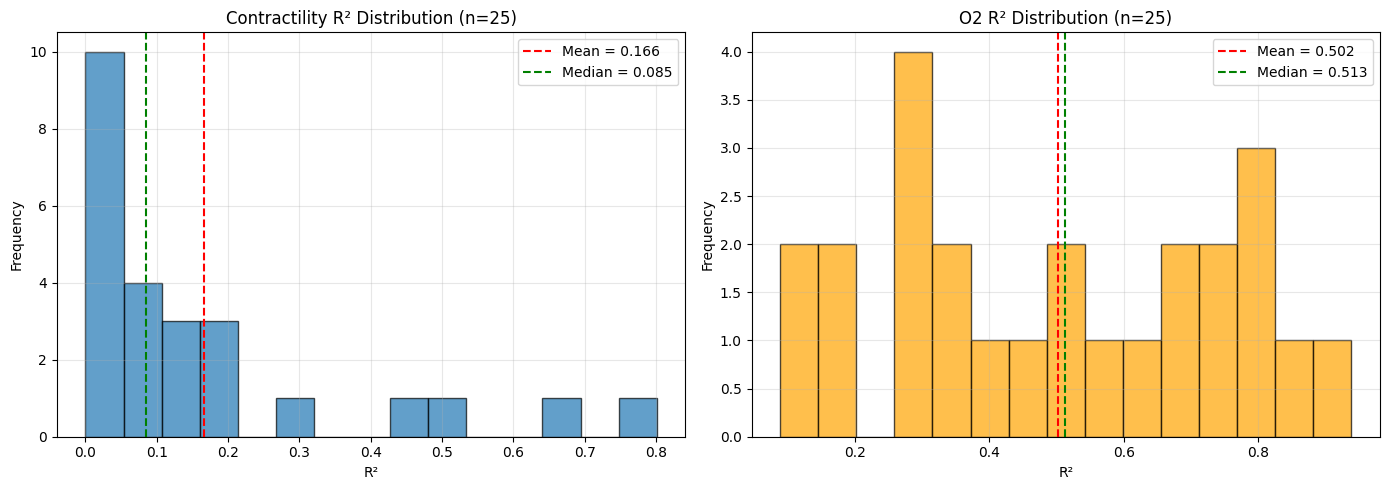

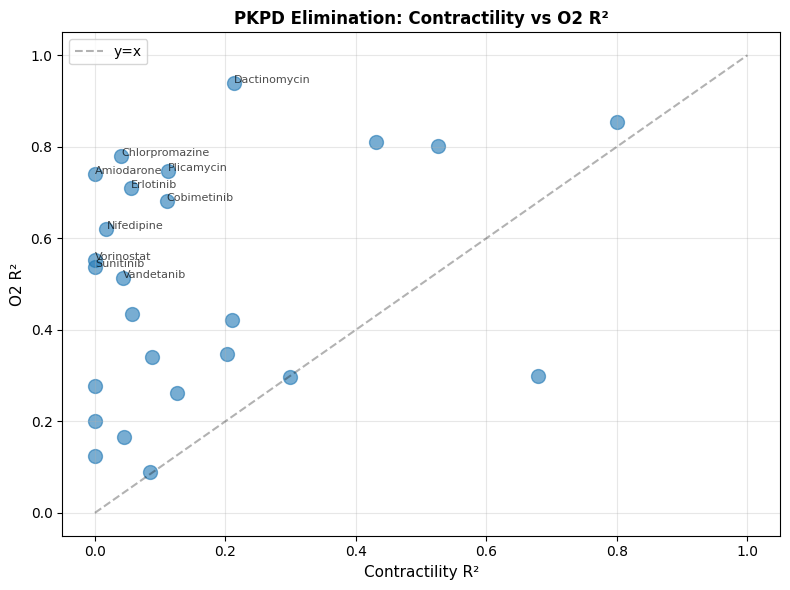

In [38]:
# Visualize R² comparison
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contractility R² distribution
axes[0].hist(pkpd_contractility_results['R2'], bins=15, alpha=0.7, edgecolor='black')
axes[0].axvline(pkpd_contractility_results['R2'].mean(), color='red', linestyle='--', 
                label=f'Mean = {pkpd_contractility_results["R2"].mean():.3f}')
axes[0].axvline(pkpd_contractility_results['R2'].median(), color='green', linestyle='--',
                label=f'Median = {pkpd_contractility_results["R2"].median():.3f}')
axes[0].set_xlabel('R²')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Contractility R² Distribution (n={len(pkpd_contractility_results)})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# O2 R² distribution
axes[1].hist(pkpd_o2_results['R2'], bins=15, alpha=0.7, edgecolor='black', color='orange')
axes[1].axvline(pkpd_o2_results['R2'].mean(), color='red', linestyle='--',
                label=f'Mean = {pkpd_o2_results["R2"].mean():.3f}')
axes[1].axvline(pkpd_o2_results['R2'].median(), color='green', linestyle='--',
                label=f'Median = {pkpd_o2_results["R2"].median():.3f}')
axes[1].set_xlabel('R²')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'O2 R² Distribution (n={len(pkpd_o2_results)})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter plot comparing Contractility vs O2 R²
merged = pd.merge(
    pkpd_contractility_results[['Drug', 'R2']],
    pkpd_o2_results[['Drug', 'R2']],
    on='Drug',
    suffixes=('_Contractility', '_O2')
)

plt.figure(figsize=(8, 6))
plt.scatter(merged['R2_Contractility'], merged['R2_O2'], alpha=0.6, s=100)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='y=x')
plt.xlabel('Contractility R²', fontsize=11)
plt.ylabel('O2 R²', fontsize=11)
plt.title('PKPD Elimination: Contractility vs O2 R²', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

# Annotate outliers
for _, row in merged.iterrows():
    if abs(row['R2_Contractility'] - row['R2_O2']) > 0.4:
        plt.annotate(row['Drug'], (row['R2_Contractility'], row['R2_O2']),
                    fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

## Step 4: Build the all-equations Excel workbook
This runs the consolidation script, which creates `equation_coefficients/all_equations_coefficients.xlsx` with one sheet per equation.


In [39]:
# Cell #27: Consolidation Script Functions
# Depends on: 2 (path setup)
# This cell contains the consolidation logic - outputs Excel format matching example file

import pandas as pd
import numpy as np
import re
from pathlib import Path
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows

# Drug classification dictionary (will be populated from data)
DRUG_CLASSIFICATION = {}

# ALL 11 equation types from example Excel
ALL_EQUATION_NAMES = [
    'polynomial',
    'modified_hill',
    'dual_exponential',
    'bivariate_gaussian',
    'gaussian_hill_hybrid',
    'gaussian_ridge',
    'pkpd_elimination',
    'adaptive_response',
    'recovery_model',
    'cumulative_exposure',
    'biphasic_response'
]

# Equation definitions with formulas and parameters
EQUATION_DEFINITIONS = {
    'polynomial': {
        'name': 'Polynomial (Eq4)',
        'formula': 'R(C,t) = R0 + a1*C + a2*t + a3*C^2 + a4*t^2 + a5*C*t + a6*C^3 + a7*t^3 + a8*C^2*t + a9*C*t^2',
        'params': ['R0', 'a1_C', 'a2_t', 'a3_C2', 'a4_t2', 'a5_Ct', 'a6_C3', 'a7_t3', 'a8_C2t', 'a9_Ct2']
    },
    'modified_hill': {
        'name': 'Modified Hill',
        'formula': 'R(C,t) = R0 + Emax * (1 - exp(-kappa * ((C/Cmax)^n) * ((t/tau)^m)))',
        'params': ['R0', 'Emax', 'kappa', 'n', 'm', 'tau', 'Cmax_used', 'R2', 'N_points']
    },
    'dual_exponential': {
        'name': 'Dual Exponential (Eq1)',
        'formula': 'R(C,t) = R0 + A_benefit*(1-exp(-kb*C))*(1-exp(-t/tau_b)) - A_tox*(1-exp(-kt*C))*(1-exp(-t/tau_t))',
        'params': ['R0', 'A_benefit', 'A_tox', 'kb', 'kt', 'tau_b', 'tau_t', 'nb', 'nt', 'mb', 'mt', 'Cmax_used', 'R2', 'N_points']
    },
    'bivariate_gaussian': {
        'name': 'Bivariate Gaussian (Eq2)',
        'formula': 'R(C,t) = R0 + Sum of Gaussian components',
        'params': ['R0', 'A1', 'A2', 'muC1', 'muT1', 'sigC1', 'sigT1', 'rho1', 'muC2', 'muT2', 'sigC2', 'sigT2', 'rho2', 'Cmax_used', 'R2', 'N_points']
    },
    'gaussian_hill_hybrid': {
        'name': 'Gaussian Hill Hybrid (Eq3)',
        'formula': 'R(C,t) = R0 + Hill*Gaussian components',
        'params': ['R0', 'Emax', 'EC50', 'sigC', 'sigT', 'n', 'A', 'm', 'muC', 'muT', 'Cmax_used', 'R2', 'N_points']
    },
    'gaussian_ridge': {
        'name': 'Gaussian Ridge',
        'formula': 'R(C,t) = R0 + A*exp(-((C-muC)^2/(2*sigC^2) + (t-muT)^2/(2*sigT^2)))',
        'params': ['R0', 'A', 'muC', 'muT', 'sigC', 'sigT', 'Cmax_used', 'R2', 'N_points']
    },
    'pkpd_elimination': {
        'name': 'PK-PD with Elimination',
        'formula': 'R(C0, t) = R0 + Emax * (1 - exp(-kappa * (C0/Cmax * exp(-k_elim * t))^n * (t/tau)^m))',
        'params': ['R0', 'Emax', 'kappa', 'n', 'm', 'tau', 'k_elim', 'Cmax_used', 'R2', 'N_points']
    },
    'adaptive_response': {
        'name': 'Adaptive Response',
        'formula': 'R(C,t) = R0 + E_init*(1-exp(-k_on*C*t)) - E_adapt*(1-exp(-k_adapt*t))',
        'params': ['R0', 'E_init', 'E_adapt', 'k_on', 'k_adapt', 'Cmax_used', 'R2', 'N_points']
    },
    'recovery_model': {
        'name': 'Recovery Model',
        'formula': 'R(C,t) = R0 + E_damage*(1-exp(-k_damage*C*t)) * exp(-k_recovery*t)',
        'params': ['R0', 'E_damage', 'k_damage', 'k_recovery', 'Cmax_used', 'R2', 'N_points']
    },
    'cumulative_exposure': {
        'name': 'Cumulative Exposure',
        'formula': 'R(C,t) = R0 + Emax*(1-exp(-kappa*(C*t)^n))',
        'params': ['R0', 'Emax', 'kappa', 'n', 'Cmax_used', 'R2', 'N_points']
    },
    'biphasic_response': {
        'name': 'Biphasic Response',
        'formula': 'R(C,t) = R0 + E1*(C/EC50_1)^n1/(1+(C/EC50_1)^n1) * f1(t) + E2*(C/EC50_2)^n2/(1+(C/EC50_2)^n2) * f2(t)',
        'params': ['R0', 'E1', 'E2', 'EC50_1', 'EC50_2', 'n1', 'n2', 'tau1', 'tau2', 'Cmax_used', 'R2', 'N_points']
    },
    'hormesis_v0': {
        'name': 'Hormesis V0 (Biphasic)',
        'formula': 'R(C,t) = R0 + benefit - toxicity',
        'params': ['R0', 'E_benefit', 'E_tox', 'EC50_b_norm', 'TC50_norm', 'n_b', 'n_t', 'tau_b', 'tau_t', 'Cmax_used', 'R2', 'N_points']
    }
}

def load_drug_classification_from_coefficients(coeff_files):
    """Extract drug classification from existing coefficient files."""
    global DRUG_CLASSIFICATION
    DRUG_CLASSIFICATION = {}

    for coeff_file in coeff_files:
        if not Path(coeff_file).exists():
            continue
        try:
            df = pd.read_csv(coeff_file)
            if 'Drug' in df.columns and 'Arrhythmia' in df.columns:
                for _, row in df.iterrows():
                    drug = str(row['Drug']).strip()
                    if drug not in DRUG_CLASSIFICATION:
                        DRUG_CLASSIFICATION[drug] = {
                            'Arrhythmia': str(row.get('Arrhythmia', 'false')),
                            'heart_damage': str(row.get('heart_damage', row.get('Cardiotoxicity', 'false'))),
                            'Concern': str(row.get('Concern', 'no')).lower()
                        }
        except Exception as e:
            print(f"  Warning: Could not load classification from {coeff_file}: {e}")

    if DRUG_CLASSIFICATION:
        print(f"Loaded classification for {len(DRUG_CLASSIFICATION)} drugs from coefficient files")
    else:
        print("No drug classification found, using defaults")

def load_drug_classification_from_excel(excel_path, sheet_name='pkpd_elimination'):
    """Load drug classification from the example Excel file."""
    global DRUG_CLASSIFICATION
    try:
        df = pd.read_excel(excel_path, sheet_name=sheet_name, header=1)
        df.columns = df.columns.str.strip()
        for _, row in df.iterrows():
            drug = str(row['Drug']).strip()
            DRUG_CLASSIFICATION[drug] = {
                'Arrhythmia': str(row.get('Arrhythmia', 'false')),
                'heart_damage': str(row.get('heart_damage', 'false')),
                'Concern': str(row.get('Concern', 'no')).lower()
            }
        print(f"Loaded classification for {len(DRUG_CLASSIFICATION)} drugs from {excel_path}")
    except Exception as e:
        print(f"Could not load classification from Excel: {e}")

def normalize_drug_name(name):
    """Normalize drug name for matching."""
    name_str = str(name).lower()
    name_str = re.sub(r'\s+(of|the)\s*$', '', name_str)
    name_str = re.sub(r'\s|\(.*?\)', '', name_str)
    return name_str

def get_drug_classification(drug_name):
    """Get classification for a drug name."""
    drug_name_lower = drug_name.lower()
    for key, value in DRUG_CLASSIFICATION.items():
        if key.lower() == drug_name_lower:
            return value

    normalized = normalize_drug_name(drug_name)
    for key, value in DRUG_CLASSIFICATION.items():
        if normalize_drug_name(key) == normalized:
            return value

    return {'Arrhythmia': 'false', 'heart_damage': 'false', 'Concern': 'no'}

def get_sort_key(drug_name):
    """Get sort key for organizing drugs by classification."""
    classification = get_drug_classification(drug_name)
    concern_order = {'most': 0, 'less': 1, 'no': 2}
    bool_order = {'true': 0, 'false': 1}

    return (
        concern_order.get(classification['Concern'], 2),
        bool_order.get(classification.get('heart_damage', 'false'), 1),
        bool_order.get(classification['Arrhythmia'], 1),
        drug_name.lower()
    )

def consolidate_coefficients(eq_name, contractility_file, o2_file, output_file):
    """Consolidate Contractility and O2 coefficient files into a single CSV."""
    eq_def = EQUATION_DEFINITIONS.get(eq_name, {})
    contractility_file = Path(contractility_file)
    o2_file = Path(o2_file)
    output_file = Path(output_file)

    try:
        df_contractility = pd.read_csv(contractility_file)
        print(f"  Loaded Contractility: {len(df_contractility)} drugs")
    except FileNotFoundError:
        print(f"  Warning: {contractility_file} not found")
        return False

    try:
        df_o2 = pd.read_csv(o2_file)
        print(f"  Loaded O2: {len(df_o2)} drugs")
    except FileNotFoundError:
        print(f"  Warning: {o2_file} not found")
        return False

    # Normalize for matching
    df_contractility['DrugKey'] = df_contractility['Drug'].apply(normalize_drug_name)
    df_o2['DrugKey'] = df_o2['Drug'].apply(normalize_drug_name)

    # Get parameter columns (exclude metadata)
    exclude_cols = {'Drug', 'DrugKey', 'Arrhythmia', 'heart_damage', 'Cardiotoxicity', 'Concern'}
    param_cols = [c for c in df_contractility.columns if c not in exclude_cols]

    # Get all unique drugs
    all_drug_keys = sorted(
        set(df_contractility['DrugKey'].unique()) | set(df_o2['DrugKey'].unique()),
        key=lambda k: get_sort_key(
            df_contractility[df_contractility['DrugKey']==k]['Drug'].iloc[0]
            if k in df_contractility['DrugKey'].values
            else df_o2[df_o2['DrugKey']==k]['Drug'].iloc[0]
        )
    )

    # Build consolidated data
    consolidated_rows = []
    for drug_key in all_drug_keys:
        row_c = df_contractility[df_contractility['DrugKey'] == drug_key]
        row_o = df_o2[df_o2['DrugKey'] == drug_key]

        drug_name = row_c['Drug'].iloc[0] if len(row_c) > 0 else row_o['Drug'].iloc[0]
        classification = get_drug_classification(drug_name)

        row_data = {
            'Drug': drug_name,
            'Arrhythmia': classification['Arrhythmia'],
            'heart_damage': classification.get('heart_damage', 'false'),
            'Concern': classification['Concern']
        }

        # Add Contractility params
        for col in param_cols:
            row_data[col] = row_c[col].iloc[0] if len(row_c) > 0 else np.nan

        # Add O2 params with _o2 suffix
        for col in param_cols:
            row_data[f'{col}_o2'] = row_o[col].iloc[0] if len(row_o) > 0 else np.nan

        consolidated_rows.append(row_data)

    df_consolidated = pd.DataFrame(consolidated_rows)

    # Write CSV in two-row header format
    output_file.parent.mkdir(parents=True, exist_ok=True)

    with open(output_file, 'w', encoding='utf-8') as f:
        # Comment header
        f.write(f"# Equation: {eq_def.get('name', eq_name)}\n")
        f.write(f"# {eq_def.get('formula', '')}\n")
        f.write(f"# Parameters: {eq_def.get('params', [])}\n#\n")

        # Row 0: Group headers
        # Drug, Contractility (spans classification + params), blank, O2 (spans params)
        group_row = ['Drug', 'Contractility']
        group_row.extend([''] * (3 + len(param_cols) - 1))  # 3 classification + params - 1 for Contractility label
        group_row.append('')  # separator
        group_row.append('O2')
        group_row.extend([''] * (len(param_cols) - 1))  # O2 params
        f.write(','.join(group_row) + '\n')

        # Row 1: Column names
        col_row = ['Drug', 'Arrhythmia', 'heart_damage', 'Concern']
        col_row.extend(param_cols)
        col_row.append('')  # separator
        col_row.extend(param_cols)
        f.write(','.join(col_row) + '\n')

        # Data rows
        for _, row in df_consolidated.iterrows():
            data_row = [
                str(row['Drug']),
                str(row['Arrhythmia']),
                str(row.get('heart_damage', 'false')),
                str(row['Concern'])
            ]
            # Contractility values
            for col in param_cols:
                val = row[col]
                data_row.append('' if pd.isna(val) else str(val))
            data_row.append('')  # separator
            # O2 values
            for col in param_cols:
                val = row.get(f'{col}_o2', np.nan)
                data_row.append('' if pd.isna(val) else str(val))
            f.write(','.join(data_row) + '\n')

    print(f"  Consolidated {len(df_consolidated)} drugs -> {output_file.name}")
    return True

def create_excel_from_coefficients(coeff_dir, output_excel, drug_classification_source=None):
    """Create Excel file with all equation coefficients in proper two-row header format."""
    print(f"\n{'='*80}")
    print("CREATING EXCEL FILE FROM COEFFICIENT CSVs")
    print(f"{'='*80}\n")

    coeff_dir = Path(coeff_dir)
    output_excel = Path(output_excel)

    # Look for consolidated CSV files (not _contractility.csv or _o2.csv)
    csv_files = []
    for f in coeff_dir.glob('*_coefficients.csv'):
        name = f.name.lower()
        if not name.endswith('_contractility.csv') and not name.endswith('_o2.csv'):
            csv_files.append(f)

    if not csv_files:
        print("  No consolidated coefficient CSV files found")
        return None

    print(f"Found {len(csv_files)} consolidated CSV files")

    # Delete existing output
    if output_excel.exists():
        output_excel.unlink()
        print(f"Deleted existing file: {output_excel}\n")

    workbook = Workbook()
    if 'Sheet' in workbook.sheetnames:
        workbook.remove(workbook['Sheet'])

    success_count = 0

    for csv_file in sorted(csv_files):
        eq_name = csv_file.stem.replace('_coefficients', '')

        try:
            with open(csv_file, 'r', encoding='utf-8') as f:
                lines = f.readlines()

            # Skip comment lines, find the group header row and column header row
            header_idx = None
            col_idx = None
            for i, line in enumerate(lines):
                stripped = line.strip()
                if stripped.startswith('#'):
                    continue
                # First non-comment line with Drug should be group header
                if 'Drug' in stripped and header_idx is None:
                    header_idx = i
                    col_idx = i + 1
                    break

            if col_idx is None or col_idx >= len(lines):
                print(f"  Skipping {eq_name}: Could not find headers")
                continue

            # Parse headers
            group_headers = [h.strip() for h in lines[header_idx].split(',')]
            col_names = [c.strip() for c in lines[col_idx].split(',')]

            # Parse data rows
            data_rows = []
            for line in lines[col_idx + 1:]:
                stripped = line.strip()
                if stripped:
                    data_rows.append([v.strip() for v in stripped.split(',')])

            if not data_rows:
                print(f"  Skipping {eq_name}: No data rows")
                continue

            # Create sheet
            sheet = workbook.create_sheet(title=eq_name)

            # Write Row 1 (group headers)
            for c, label in enumerate(group_headers, 1):
                if label:
                    sheet.cell(1, c, label)

            # Write Row 2 (column names)
            for c, name in enumerate(col_names, 1):
                sheet.cell(2, c, name)

            # Write data rows starting at Row 3
            for r, row_values in enumerate(data_rows, 3):
                for c, val in enumerate(row_values, 1):
                    if val:
                        try:
                            # Try to convert to number
                            cell_val = float(val)
                        except ValueError:
                            cell_val = val
                        sheet.cell(r, c, cell_val)

            print(f"  Added sheet: {eq_name} ({len(data_rows)} drugs)")
            success_count += 1

        except Exception as e:
            print(f"  Failed: {eq_name}: {e}")
            import traceback
            traceback.print_exc()

    if len(workbook.sheetnames) > 0:
        workbook.active = workbook[workbook.sheetnames[0]]
        workbook.save(output_excel)
        print(f"\n{'='*80}")
        print(f"Excel file created: {output_excel}")
        print(f"Successfully added {success_count}/{len(csv_files)} sheets")
        print(f"{'='*80}\n")
        return output_excel
    else:
        print("No sheets were created - check the CSV files")
        return None

def read_coefficients_excel(excel_path, sheet_name='pkpd_elimination'):
    """
    Read coefficients from Excel file in the two-row header format.
    Returns DataFrame with .1 suffix for O2 parameters (matching expected column naming).
    """
    df_raw = pd.read_excel(excel_path, sheet_name=sheet_name, header=None)

    group_headers = df_raw.iloc[0].tolist()
    col_names = df_raw.iloc[1].tolist()

    # Find O2 section start
    o2_start_idx = None
    for i, g in enumerate(group_headers):
        if pd.notna(g) and str(g).strip() == 'O2':
            o2_start_idx = i
            break

    # Build column names with .1 suffix for O2 params
    final_cols = []
    param_cols_seen = set()

    for i, col in enumerate(col_names):
        col_str = str(col).strip() if pd.notna(col) else ''

        if i == 0:
            final_cols.append('Drug')
        elif o2_start_idx and i >= o2_start_idx:
            if col_str in ['Arrhythmia', 'heart_damage', 'Concern', '']:
                final_cols.append(col_str)
            elif col_str in param_cols_seen:
                final_cols.append(f'{col_str}.1')
            else:
                final_cols.append(col_str)
        else:
            if col_str not in ['Drug', 'Arrhythmia', 'heart_damage', 'Concern', '']:
                param_cols_seen.add(col_str)
            final_cols.append(col_str)

    df_data = df_raw.iloc[2:].copy()
    df_data.columns = final_cols
    df_data = df_data.reset_index(drop=True)
    df_data.columns = df_data.columns.str.strip()
    df_data = df_data.loc[:, df_data.columns != '']

    return df_data

print("Consolidation functions loaded successfully")
print(f"  - ALL_EQUATION_NAMES: {len(ALL_EQUATION_NAMES)} equations defined")
print("  - consolidate_coefficients(): Merges Contractility + O2 CSVs")
print("  - create_excel_from_coefficients(): Creates multi-sheet Excel")
print("  - read_coefficients_excel(): Reads two-row header Excel format")


Consolidation functions loaded successfully
  - ALL_EQUATION_NAMES: 11 equations defined
  - consolidate_coefficients(): Merges Contractility + O2 CSVs
  - create_excel_from_coefficients(): Creates multi-sheet Excel
  - read_coefficients_excel(): Reads two-row header Excel format


In [40]:
# Cell #28: Create Consolidated Excel File
# Depends on: 27 (consolidation functions), equation fitting cells
# This cell rebuilds the all_equations_coefficients.xlsx with ALL equation types

import subprocess
import sys

# FLAGS - Set these to control behavior
RUN_REBUILD = True  # Set to True to rebuild the Excel file

if RUN_REBUILD:
    print("\n" + "="*80)
    print("REBUILDING all_equations_coefficients.xlsx")
    print("="*80 + "\n")

    # Try to load classification from example Excel first (most reliable)
    example_excel = Path(r'C:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Picking Equations\all_equations_coefficients_example.xlsx')
    if example_excel.exists():
        load_drug_classification_from_excel(example_excel, 'pkpd_elimination')
    else:
        # Fallback to loading from existing coefficient CSV files
        existing_csvs = list(COEFF_DIR.glob('*_coefficients_contractility.csv'))
        load_drug_classification_from_coefficients(existing_csvs)

    # ALL equations to consolidate (matching example Excel sheets)
    equations_to_consolidate = []

    print("Checking for equation coefficient files...\n")

    # Check all 11 equation types
    for eq_name in ALL_EQUATION_NAMES:
        c_file = COEFF_DIR / f'{eq_name}_coefficients_contractility.csv'
        o_file = COEFF_DIR / f'{eq_name}_coefficients_o2.csv'

        if c_file.exists() and o_file.exists():
            equations_to_consolidate.append(eq_name)
            print(f"  Found: {eq_name}")
        else:
            print(f"  Missing: {eq_name}")
            if not c_file.exists():
                print(f"    - {c_file.name}")
            if not o_file.exists():
                print(f"    - {o_file.name}")

    print(f"\n{'='*80}")
    print(f"Consolidating {len(equations_to_consolidate)} equations...")
    print(f"{'='*80}\n")

    # Consolidate each equation
    for eq_name in equations_to_consolidate:
        print(f"\nProcessing {eq_name}...")
        consolidate_coefficients(
            eq_name,
            COEFF_DIR / f'{eq_name}_coefficients_contractility.csv',
            COEFF_DIR / f'{eq_name}_coefficients_o2.csv',
            COEFF_DIR / f'{eq_name}_coefficients.csv'
        )

    # Create Excel file
    output_excel = PROJECT_ROOT / 'EQN_Coefficients' / 'all_equations_coefficients.xlsx'
    create_excel_from_coefficients(COEFF_DIR, output_excel)

    if output_excel.exists():
        print(f"\nComplete! Excel file saved to: {output_excel}")
        print(f"\nExpected sheets: {len(ALL_EQUATION_NAMES)}")
        print(f"Created sheets: {len(equations_to_consolidate)}")

        if len(equations_to_consolidate) < len(ALL_EQUATION_NAMES):
            missing = set(ALL_EQUATION_NAMES) - set(equations_to_consolidate)
            print(f"\nMissing equations (need to fit these): {missing}")
            print("\nTo generate missing equations:")
            print("  1. Set the appropriate RECALCULATE_* or RECOMPUTE_* flag to True")
            print("  2. Run the equation fitting cell")
            print("  3. Re-run this cell to rebuild the Excel file")
    else:
        print("\nError: Excel file was not created")

else:
    print('Skip rebuild. Set RUN_REBUILD=True to regenerate all_equations_coefficients.xlsx')



REBUILDING all_equations_coefficients.xlsx

Loaded classification for 25 drugs from C:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Picking Equations\all_equations_coefficients_example.xlsx
Checking for equation coefficient files...

  Missing: polynomial
    - polynomial_coefficients_contractility.csv
    - polynomial_coefficients_o2.csv
  Missing: modified_hill
    - modified_hill_coefficients_contractility.csv
    - modified_hill_coefficients_o2.csv
  Missing: dual_exponential
    - dual_exponential_coefficients_contractility.csv
    - dual_exponential_coefficients_o2.csv
  Missing: bivariate_gaussian
    - bivariate_gaussian_coefficients_contractility.csv
    - bivariate_gaussian_coefficients_o2.csv
  Missing: gaussian_hill_hybrid
    - gaussian_hill_hybrid_coefficients_contractility.csv
    - gaussian_hill_hybrid_coefficients_o2.csv
  Missing: gaussian_ridge
    - gaussian_ridge_coefficients_contractility.csv
    - gaussian_ridge_coefficients_o2.csv
  Missing: pkpd_

## Step 5: R2 summary for all equations (mean data)
This reads all consolidated coefficient files and summarizes R2 for Contractility and O2.


In [41]:
# Summary of R² across all equations
# This cell only runs if coefficient files have been generated

def list_consolidated_coeff_files():
    """Find consolidated coefficient CSV files in COEFF_DIR"""
    files = []
    for p in COEFF_DIR.glob('*_coefficients.csv'):
        name = p.name.lower()
        # Skip the split contractility/o2 files, only get consolidated ones
        if name.endswith('_contractility.csv') or name.endswith('_o2.csv'):
            continue
        files.append(p)
    return sorted(files)

# Find all coefficient files
coeff_files = list_consolidated_coeff_files()

if not coeff_files:
    print("⚠️  No consolidated coefficient files found yet.")
    print(f"   Looking in: {COEFF_DIR}")
    print("\nTo generate coefficient files:")
    print("  1. Run the equation fitting cells (set RECOMPUTE_HORMESIS=True, RECALCULATE_PKPD=True, etc.)")
    print("  2. Set WRITE_HORMESIS_OUTPUT=True and other output flags to save CSV files")
    print("  3. Run the consolidation cell (set RUN_REBUILD=True) to create consolidated files")
else:
    print(f"Found {len(coeff_files)} coefficient files:\n")

    rows = []
    for path in coeff_files:
        eq_name = path.stem.replace('_coefficients', '')
        print(f"  Processing {eq_name}...")

        # Special handling for equations with variables in memory
        if eq_name == 'hormesis_v0' and 'df_hormesis_contract' in globals():
            r2_contract = df_hormesis_contract['R2']
            r2_o2 = df_hormesis_o2['R2'] if 'df_hormesis_o2' in globals() else None
            n_drugs = len(df_hormesis_contract)
        elif eq_name == 'pkpd_elimination' and 'pkpd_contractility_recalc' in globals():
            r2_contract = pkpd_contractility_recalc['R2']
            r2_o2 = pkpd_o2_recalc['R2'] if 'pkpd_o2_recalc' in globals() else None
            n_drugs = len(pkpd_contractility_recalc)
        else:
            # Load from CSV file
            try:
                df = read_coeff_csv(path)
                df = df[~df['Drug'].apply(should_exclude_drug)].reset_index(drop=True)
                r2_contract, r2_o2 = extract_r2_columns(df)
                n_drugs = len(df)
            except Exception as e:
                print(f"    ⚠️  Error loading {eq_name}: {e}")
                continue

        rows.append({
            'equation': eq_name,
            'n_drugs': n_drugs,
            'contractility_r2_mean': float(r2_contract.mean()) if r2_contract is not None else np.nan,
            'o2_r2_mean': float(r2_o2.mean()) if r2_o2 is not None else np.nan
        })

    # Create summary DataFrame
    r2_summary = pd.DataFrame(rows)

    print(f"\n{'='*80}")
    print("R² SUMMARY (sorted by Contractility R²)")
    print(f"{'='*80}")
    display(r2_summary.sort_values('contractility_r2_mean', ascending=False))

    print(f"\n{'='*80}")
    print("R² SUMMARY (sorted by O2 R²)")
    print(f"{'='*80}")
    display(r2_summary.sort_values('o2_r2_mean', ascending=False))

    # Save summary
    output_path = OUTPUT_DIR / 'all_equations_r2_summary.csv'
    r2_summary.to_csv(output_path, index=False)
    print(f"\n✓ Saved: {output_path}")


Found 1 coefficient files:

  Processing hormesis_v0...

R² SUMMARY (sorted by Contractility R²)


,equation,n_drugs,contractility_r2_mean,o2_r2_mean
0,hormesis_v0,25,0.398664,0.458892



R² SUMMARY (sorted by O2 R²)


,equation,n_drugs,contractility_r2_mean,o2_r2_mean
0,hormesis_v0,25,0.398664,0.458892



✓ Saved: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Picking Equations\outputs\all_equations_r2_summary.csv


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = r2_summary.dropna(subset=['contractility_r2_mean', 'o2_r2_mean'])

plt.figure(figsize=(6, 5))
sns.regplot(
    data=plot_df,
    x='contractility_r2_mean',
    y='o2_r2_mean',
    scatter_kws={'s': 60, 'alpha': 0.8},
    line_kws={'color': 'black'}
)
for _, row in plot_df.iterrows():
    plt.text(row['contractility_r2_mean'], row['o2_r2_mean'], row['equation'],
             fontsize=8, ha='left', va='bottom')
plt.xlabel('Contractility R2 mean')
plt.ylabel('O2 R2 mean')
plt.title('Equation R2 comparison')
plt.tight_layout()
plt.show()


NameError: name 'r2_summary' is not defined